# Train-Free Segmentation in MRI with Cubical Persistent Homology
## II/III: Cardiac
Anton François & Raphaël Tinarrage

In [ ]:
# TDA
import persim, cripser

# Image
import scipy, skimage
import matplotlib

# Anton
from parse_brats_for_raph import *
import nibabel as nib
import vedo

# Misc
import itertools, glob
import pandas as pd

# Comments
import sys, time, datetime

def ChronometerStart(msg='Start... '):
    start_time = time.time()
    sys.stdout.write(msg); sys.stdout.flush()
    return start_time
def ChronometerStop(start_time, method='ms', linebreak='\n'):
    elapsed_time_secs = time.time() - start_time
    if method == 'ms':
        msg = 'Execution time: '+repr(round(elapsed_time_secs*1000))+' ms.'+linebreak
    if method == 's':
        msg = 'Execution time: '+repr(round(elapsed_time_secs))+' s.'+linebreak
    sys.stdout.write(msg); sys.stdout.flush()    
def ChronometerTick(start_time, i, i_total, msg):    
    elapsed_time_secs = time.time() - start_time
    expected_time_secs = (i_total-i-1)/(i+1)*elapsed_time_secs
    msg1 = 'It '+repr(i+1)+'/'+repr(i_total)+'. '
    msg2 = 'Duration %s ' % datetime.timedelta(seconds=round(elapsed_time_secs))
    msg3 = 'Expected remaining time %s.' % datetime.timedelta(seconds=round(expected_time_secs))
    sys.stdout.write('\r'+msg+msg1+msg2+msg3)
    if i>=i_total-1: sys.stdout.write('\n')
        
''' FUNCTIONS TO PROCESS IMAGES '''

def argmax_image(img):
    return np.unravel_index(img.argmax(), img.shape)

def GetConnectedComponent(img, pos, t):
    '''
    Get the connected component of the voxel pos = (x,y,z) at time t.
    The output is a binary image.
    Background value of img must be 0 (as conventional).
    '''
    imt = (img>=t)*1
    if imt[pos[0],pos[1],pos[2]]==0: # The voxel pos is not active at time t
        CC = img*0
    else:    
        labels = skimage.measure.label(imt, background=0)
        labeltumor = labels[pos[0],pos[1],pos[2]]
        CC = (labels == labeltumor)*1
        if labeltumor==0: print('Problem! The label is background :(')
    return CC

def get_largest_CC(img, t, verbose=False):    
    if verbose: start_time = ChronometerStart('Get largest connected component... ')
    imgt = (img>=t)*1
    Labels = skimage.measure.label(imgt, background=0)
    nlabels = np.max(Labels)
    CardinalLabels = [0]+[np.sum(Labels==i) for i in range(1,nlabels)]
    ilabel = np.argmax(CardinalLabels)
    CC = (Labels==ilabel)*1    
    if verbose: ChronometerStop(start_time, method='s')
    return CC

def SEN(seg_1,seg_2, verbose=False):
    prod_seg = seg_1 * seg_2
    if seg_1.sum()==0: sen = 1
    else:              sen = prod_seg.sum() / seg_1.sum()
    return sen

def GetSensitivities(seg_1,seg_2, verbose=False):
    sens = {l:SEN((seg_1==l)*1, (seg_2==l)*1, verbose=False) for l in [1,2,4]}
    sens[0] = SEN((seg_1>0)*1, (seg_2>0)*1, verbose=False)
    return sens

def ACC(seg_1,seg_2, verbose=False):
    prod_seg = seg_1 * seg_2
    prod_seg_complement = (1-seg_1) * (1-seg_2)
    acc = (prod_seg.sum()+prod_seg_complement.sum())/np.prod(np.shape(seg_1))
    return acc

def GetAccuracies(seg_1,seg_2, verbose=False):
    accs = {l:ACC((seg_1==l)*1, (seg_2==l)*1, verbose=False) for l in [1,2,4]}
    accs[0] = ACC((seg_1>0)*1, (seg_2>0)*1, verbose=False)
    return accs

def DICE(seg_1,seg_2, verbose=False):
    prod_seg = seg_1 * seg_2
    sum_seg = seg_1 + seg_2
    if sum_seg.sum()==0: dice = 1
    else: dice = 2 * prod_seg.sum() / sum_seg.sum()
    if verbose:
        # Non-symmetric scores
        diceleft  = prod_seg.sum() / seg_1.sum()
        diceright = prod_seg.sum() / seg_2.sum()
        print('Sørensen–Dice coefficient: ',round(dice,3), round(diceleft,3), round(diceright,3))
    return dice

def GetDICEs(seg_1,seg_2, verbose=False):
    dices = {l:DICE((seg_1==l)*1, (seg_2==l)*1, verbose=False) for l in [1,2,3]}
    dices[0] = DICE((seg_1>0)*1, (seg_2>0)*1, verbose=False)
    if verbose: print('Sørensen–Dice coefficients:', {l:round(dices[l],3) for l in [1,2,3]})
    return dices 

def OpenBRATS(i,verbose=False):
    '''
    i must be between 0 and 1249 included
    '''
    indices_BRATS2021 = list(range(707))+list(range(708,1089))+list(range(1090,1099))+list(range(1100,1253))
        #images that I can open on my laptop
    if i<0 or 1>=1250:
        print('Error in OpenBRATS! i = ', i)
        return None
    else:    
        n_image = indices_BRATS2021[i]
        # Open t1ce
        pb = parse_brats(brats_list=None,brats_folder='2021',modality='t1ce')
        img_t1ce, _ = pb(n_image,to_torch=False)
        # Open flair
        pb = parse_brats(brats_list=None,brats_folder='2021',modality='flair')
        img_flair, seg_medecin = pb(n_image,to_torch=False)
        seg_medecin = seg_medecin.get_fdata()
        if verbose: print(pb.brats_list[n_image])
        return pb, img_flair, img_t1ce, seg_medecin
    
''' MAIN ALGORITHM '''

def Preprocess(img_flair,img_t1ce,sigma,normalize='max',do_enhance=[False,False]):
    '''
    do_enhance can be True, False, or a list [True,True], [True, False], ...
    '''
    # Enhance image
    mask = (img_flair!=0)
    if do_enhance==True:
        img_flair = skimage.filters.rank.enhance_contrast(img_flair,footprint=skimage.morphology.ball(4), mask=mask)
        img_t1ce = skimage.filters.rank.enhance_contrast(img_t1ce,footprint=skimage.morphology.ball(4), mask=mask)
    elif do_enhance is not False:
        if do_enhance[0]:
            img_flair = skimage.filters.rank.enhance_contrast(img_flair,footprint=skimage.morphology.ball(4), mask=mask)
        if do_enhance[1]:
            img_t1ce = skimage.filters.rank.enhance_contrast(img_t1ce,footprint=skimage.morphology.ball(4), mask=mask)

    # Normalize images
    if normalize=='max':
        img_flair = img_flair/np.max(img_flair)
        img_t1ce = img_t1ce/np.max(img_t1ce)
    else:
        img_flair = img_flair/255
        img_t1ce = img_t1ce/255
    
    # N4 Bias Field Correction
    # see https://simpleitk.readthedocs.io/en/master/link_N4BiasFieldCorrection_docs.html
    
    # Gaussian smoothing
    if sigma>0:
        img_flair = scipy.ndimage.gaussian_filter(img_flair, sigma=sigma)    
        img_t1ce = scipy.ndimage.gaussian_filter(img_t1ce, sigma=sigma)
            
    return img_flair, img_t1ce

def suggest_t(img, N=100, dt_threshold=1, seg_medecin=None, verbose=False, plot=False):
    T = np.linspace(0,1,N)

    # Build suggestion curve
    if verbose: start_time = ChronometerStart('Suggest t... ')
    S = np.array([np.sum(img>t) for t in T])
    S_dt = (S[:-1] - S[1:])                #finite differences
    S_dt_norm = S_dt*len(S_dt)/S_dt.sum()  #S_dt_norm has integral 1, i.e., np.sum(S_dt_norm)/len(S_dt) = 1
    if verbose: ChronometerStop(start_time, method='s')
        
    # Find optimal t
    best_i = np.where(S_dt_norm>dt_threshold)[0][-1] #last value for which S_dt_norm>dt_threshold
    best_t = T[best_i+1]

    if plot:
        fig, ax = plt.subplots(1, 1, figsize = (8,2))
        plt.plot(T,S/np.max(S)*np.max(S_dt_norm),c='black', label='_nolegend_')
        plt.plot(T[0:-1],S_dt_norm, c='black', label='_nolegend_')
        plt.scatter(T[0:-1],S_dt_norm,c='black',s=10, label='_nolegend_')
        plt.axhline(dt_threshold, c='blue', label='dt_threshold') 
        plt.axvline(best_t, c='pink', label='best t')
        if seg_medecin is not None:
            groundtruth_t = np.min(img[seg_medecin>0])
            plt.axvline(groundtruth_t, c='red', label='groundtruth t')
        plt.ylim(0,np.max(S_dt_norm[1::])*1.1)
        plt.title('Suggest t, dt_threshold = '+repr(dt_threshold)); plt.legend(); plt.show()

    return best_t

# def Step1(img_flair,seg_medecin=None,method='suggest_t',dt_threshold=1,verbose=True,plot=True):
#     '''
#     method can be 'suggest_t', 'medecin' or 'medecin_hull'
#     '''        
#     if method=='suggest_t':
#         # Find best t
#         t = suggest_t(img_flair, dt_threshold=dt_threshold, seg_medecin=seg_medecin, verbose=verbose, plot=plot)

#         # Extract CC
#         seg_union = get_largest_component(img_flair, t, verbose=verbose)

#         # Fill CC with holes
#         if verbose: start_time = ChronometerStart('Fill the holes... ')
#         seg_union = scipy.ndimage.binary_fill_holes(seg_union)
#         if verbose: ChronometerStop(start_time, method='s')
            
#         # Smooth via binary closing
#         iterations = 0
#         if iterations>0: seg_union = scipy.ndimage.morphology.binary_closing(seg_union, iterations=iterations)

#     elif method=='medecin': seg_union = (seg_medecin>0)*1

#     elif method=='medecin_hull': 
#         # Take convex hull of seg_union
#         seg_union = (seg_medecin>0)*1
#         if verbose: start_time = ChronometerStart('Take convex hull... ')
#         seg_union = (seg_medecin>0)*1
#         seg_union = skimage.morphology.convex_hull_image(seg_union)
#         seg_union = seg_union*1
#         if verbose: ChronometerStop(start_time, method='s')

#     return seg_union

# def Step2(img_t1ce,seg_union,H2_features_max=5,verbose=True,plot=True):
#     # Compute PH2
#     if verbose: start_time = ChronometerStart('Compute diagram... ')
#     seg_union_t1ce = img_t1ce*seg_union
#     barcode = cripser.computePH(1-seg_union_t1ce,maxdim=3) # Compute diagram
#     H2 = [list(bar[1::]) for bar in barcode if bar[0]==2 and bar[2]<1] # Only non-infinite bars
#     H2 = [bar for _,bar in sorted(zip([bar[1]-bar[0] for bar in H2],H2))[::-1]] # Sort list H2 by persistence
#     if verbose: ChronometerStop(start_time, method='s')

#     # If empty diagram
#     if len(H2)==0: return seg_union_t1ce*0
        
#     # Plot diagram
#     if plot:
#         fig, ax = plt.subplots(1,1, figsize=(4,4))
#         persim.plot_diagrams([np.array([barcode[0][1:3]]), np.array([barcode[0][1:3]]), np.array([bar[1:3] for bar in barcode if bar[0]==3-1])])
#         plt.title('Persistence diagram of t1ce segmented',fontsize=10)

#     # Compute width of the holes of H2-features
#     i_max = min(H2_features_max,len(H2)) #number of top bars to parse
#     length_holes = []
#     for i in range(i_max):
#         bar = H2[i]
#         pos = np.array(bar[2:5]).astype(int)
#         t = bar[0]+0.0001
#         seg_contour = GetConnectedComponent(seg_union_t1ce, pos, 1-t)
#         seg_contour_filled = scipy.ndimage.binary_fill_holes(seg_contour)
#         length_holes.append( np.sum(seg_contour_filled-seg_contour) )
#     if verbose: print('Width of the holes:', {i:length_holes[i] for i in range(i_max)})
    
#     # Select the largest hole
#     i = np.argmax(length_holes)
#     bar = H2[i]
#     pos = np.array(bar[2:5]).astype(int)
#     t = bar[0]+0.0001
#     seg_contour = GetConnectedComponent(seg_union_t1ce, pos, 1-t)

#     # Plot
#     if plot: patch = plt.Circle((bar[0],bar[1]), 0.01,fill=False); ax.add_patch(patch)
#     return seg_contour

# def Step3(seg_union, seg_contour, alpha_boundary=.85,verbose=True):               
#     # 3rd step: - Classify components
#         # 1 - RED, TC  -> NECROSE INACTIVE, TUMORUS CORE
#         # 2 - BLUE, ED -> INFILTRATION, OEDEME
#         # 4 - ORANGE, ET -> NECROSE ACTIVE, ENHANCING TUMOR
#     seg_union_nocontour = seg_union - seg_contour
#     seg_nocontour_components = []
#     labels = skimage.measure.label(seg_union_nocontour, background=0)

#     N = 0 # select components with cardinal at least N
#     components = [(labels==i)*1 for i in range(1,np.max(labels)+1)]
#     components = [component for component in components if np.sum(component)>N]

#     # Classify components: TC or WT
#     seg_final = seg_contour.copy()*4 # define seg_final
#     for component in components:
#         componentdilated = scipy.ndimage.binary_dilation(component,iterations=1)
#         componentcontour = componentdilated - component
#         meanvalue = np.mean(seg_contour[np.where(componentcontour>0)])
#         if meanvalue<alpha_boundary: #sort du masque Segmentation, label 2
#             seg_final[component>0] = 2
#         else: #label 1
#             seg_final[component>0] = 1
            
#     return seg_final

''' FUNCTIONS TO PLOT '''

from matplotlib.colors import ListedColormap

# Own colormap for segmentations
cmap_segs = ListedColormap([[0,0,0,0],'tab:blue','tab:orange','tab:red'])
DLT_KW_IMAGE = dict(cmap='gray',origin='lower',vmin=0,vmax=1)
DLT_KW_SEG= dict(cmap=cmap_segs,interpolation='nearest',origin='lower')
                 
def make_3d_flat(img_3D,pos):
    ''' 
    Take a 'brain' 3D image, take 3 slices and make a long 2D image of it.
    '''
    crop = 2 #parameter
    # Cut slices
    D,H,W = img_3D.shape
    im0 = img_3D[:,:,pos[2]].T #image_slice(img_3D,slice[2],2).T
    im1 = img_3D[:,pos[1],:].T#image_slice(img_3D,slice[1],1).T
    im2 = img_3D[pos[0],:,:].T#image_slice(img_3D,slice[0],0).T
    # Crop and pad slices
    long_img = np.zeros((D,D+H+H-int(3.5*crop)))
    long_img[:D,:D-crop] = im0[:,crop//2:-crop//2]
    long_img[(D-W)//2:(D-W)//2 + W,D-int(1.7*crop):D+H-int(2.7*crop)] = im1[::-1,crop//2:-crop//2]
    long_img[(D-W)//2:(D-W)//2 + W,D+H-int(3*crop):] = im2[::-1,crop//2:]
    return long_img

def PlotSegmentation(pb,img,seg=None,pos=None,figsize=(15,5)):
    if pos is None: pos = argmax_image(img_flair)
    fig = plt.figure(figsize=figsize); ax = fig.add_subplot(1,1,1)
    ax.imshow(make_3d_flat(img,pos),cmap='gray',alpha=0.5,origin='upper')
    if seg is None: seg = img*0
    ax.imshow(make_3d_flat(seg,pos),**DLT_KW_SEG)
    ax.text(235,15,pb.brats_list[i],c='white',fontsize=20)
    plt.axis('off')
    
def PlotSuperlevelSets(image, pos=None, Times=None):
    if Times==None: Times = [0,0.05,0.3,0.5,1]

    if pos==None: 
        if image[0,0,0]==0: pos = argmax_image(image)
        else: pos = argmax_image(1-image)
    im = image[:,:,pos[2]]

    fig = plt.figure(figsize=(15,15)) # Notice the equal aspect ratio
    ax = [fig.add_subplot(1,len(Times),i+1) for i in range(len(Times))]
    ax.reverse()
    for i in range(len(Times)):
        t = Times[i]
        imt = np.zeros(np.shape(im)); imt[im<t] = 1; imt[im>=t] = 0
        ax[i].imshow(imt,origin='lower',vmin=0,vmax=1,cmap='gray')
        ax[i].set_title('t = '+repr(Times[::-1][i]), fontsize=17.5); 
        ax[i].axis('off'); ax[i].set_aspect('equal')
    fig.subplots_adjust(wspace=0.05, hspace=0)
    
def PlotSublevelSets(image, pos=None, Times=None):
    if Times==None: Times = [0,0.05,0.3,0.5,1]

    if pos==None: 
        if image[0,0,0]==0: pos = argmax_image(image)
        else: pos = argmax_image(1-image)
    im = image[:,:,pos[2]]

    fig = plt.figure(figsize=(15,15)) # Notice the equal aspect ratio
    ax = [fig.add_subplot(1,len(Times),i+1) for i in range(len(Times))]
    for i in range(len(Times)):
        t = Times[i]
        imt = np.zeros(np.shape(im)); imt[im>t] = 1; imt[im<=t] = 0
        ax[i].imshow(imt,origin='lower',vmin=0,vmax=1,cmap='gray')
        ax[i].set_title('t = '+repr(t), fontsize=17.5); 
        ax[i].axis('off'); ax[i].set_aspect('equal')
    fig.subplots_adjust(wspace=0.05, hspace=0)    
    
def BoxplotSegmentation(dic, suptitle=None):
    Titles = ['WT', 'TC', 'ED', 'ET']
    Labels = [0,1,2,4]
    DICEs_list = list(dic.values())

    plt.figure(figsize =(4*4, 2),constrained_layout=True)
    for k in range(len(Labels)):
        label = Labels[k]
        scores = [dic[i][label] for i in dic]
        ax = plt.subplot(1,len(Labels),k+1)
        ax.boxplot(scores, showmeans=True, notch = True)
        title = Titles[k]+', mean='+repr(round(np.mean(scores),2))+', med='+repr(round(np.median(scores),2))
        ax.title.set_text(title)
        ax.set_ylim(-0.01,1)
    if suptitle is not None: plt.suptitle(suptitle)

In [ ]:
def PlotSuperlevelSets(image, pos=None, Times=None):
    if Times==None: Times = [0,0.05,0.3,0.5,1]

    if pos==None: 
        if image[0,0,0]==0: pos = argmax_image(image)
        else: pos = argmax_image(1-image)
    im = image[:,:,pos[2]]

    fig = plt.figure(figsize=(15,15)) # Notice the equal aspect ratio
    ax = [fig.add_subplot(1,len(Times),i+1) for i in range(len(Times))]
    for i in range(len(Times)):
        t = Times[i]
        imt = np.zeros(np.shape(im)); imt[im<t] = 1; imt[im>=t] = 0
        ax[i].imshow(imt,origin='lower',vmin=0,vmax=1,cmap='gray')
        ax[i].set_title('t = '+repr(Times[i]), fontsize=17.5); 
        ax[i].axis('off'); ax[i].set_aspect('equal')
    fig.subplots_adjust(wspace=0.05, hspace=0)

In [ ]:
def OpenACDC(n_image, end='ED'):
    ''' 
    n_image must be between 1 and 150 included.
    <= 100: training, >= 101: testing
    
    end can be 'ED or 'ES' (end diastole, end systole)
    '''
    
    # Open image and segmentation
    n_image_str = '0'*(3-len(str(n_image)))+str(n_image)
    if n_image<=100: doc = '/home/raph/GoogleDrive/Professionnel/TDA+Brains/Code Python/data/cardiac/training/patient'+n_image_str+'/Info.cfg'
    else:            doc = '/home/raph/GoogleDrive/Professionnel/TDA+Brains/Code Python/data/cardiac/testing/patient'+n_image_str+'/Info.cfg'
    with open(doc) as f: lines = f.readlines()
    if end=='ED':
        n_ED = int(lines[0][4:6])
        n_ED_str = '0'*(2-len(str(n_ED)))+str(n_ED)
        if n_image<=100: filename = '/home/raph/GoogleDrive/Professionnel/TDA+Brains/Code Python/data/cardiac/training/patient'+n_image_str+'/patient'+n_image_str+'_frame'+n_ED_str+'.nii.gz'
        else: filename = '/home/raph/GoogleDrive/Professionnel/TDA+Brains/Code Python/data/cardiac/testing/patient'+n_image_str+'/patient'+n_image_str+'_frame'+n_ED_str+'.nii.gz'
    elif end=='ES':
        n_ES = int(lines[1][4:6])
        n_ES_str = '0'*(2-len(str(n_ES)))+str(n_ES)
        if n_image<=100: filename = '/home/raph/GoogleDrive/Professionnel/TDA+Brains/Code Python/data/cardiac/training/patient'+n_image_str+'/patient'+n_image_str+'_frame'+n_ES_str+'.nii.gz'
        else: filename = '/home/raph/GoogleDrive/Professionnel/TDA+Brains/Code Python/data/cardiac/testing/patient'+n_image_str+'/patient'+n_image_str+'_frame'+n_ES_str+'.nii.gz'
    img = nib_load(filename).get_fdata(); 
    img /= np.max(img)

    filename = filename[0:-7]+'_gt.nii.gz'
    seg_medecin = nib_load(filename).get_fdata(); 

    return img, seg_medecin

# Plot images

In [ ]:
' Figure article - coronal '

n_image = 2
z_pos   = 3 
img, img_seg = OpenACDC(n_image, end='ED')

fig = plt.figure(figsize=(10,5)); fig.subplots_adjust(wspace=0.1, hspace=0.05)
n = 20
ax = fig.add_subplot(1,2,1); ax.axis('off')
ax.imshow(img[n:,n:,z_pos],cmap='gray',alpha=1,origin='lower'); 

ax = fig.add_subplot(1,2,2); ax.axis('off')
ax.imshow(img[n:,n:,z_pos],cmap='gray',alpha=.6,origin='lower'); 
ax.imshow(img_seg[n:,n:,z_pos],alpha=0.75,**DLT_KW_SEG); 

plt.savefig('Images/coronal_examples.pdf', format="pdf", bbox_inches="tight")

In [ ]:
' Figure article - coronal '

# for n_image in range(21,38+1):
z_pos = [int(i) for i in np.linspace(2,10-2,2)]
figsize=(2*len(z_pos)*3,3*2)
fig = plt.figure(figsize=figsize); 
fig.subplots_adjust(wspace=0.05, hspace=0.05)

for i_image, n_image in enumerate([7]):
    for j, end in enumerate(['ED', 'ES']):
        # Open image
        img, img_seg = OpenACDC(n_image, end=end)
        for k, plot in enumerate(['im', 'seg']):
            # Plot slices
            for i in range(len(z_pos)):
                ax = fig.add_subplot(2,2*len(z_pos),i+1+i_image*len(z_pos)+j*len(z_pos)*2+k+i); ax.axis('off')
                if plot=='im':
                    ax.imshow(img[:,:,z_pos[i]].T,cmap='gray',alpha=1,origin='lower'); 
                if plot=='seg':
                    ax.imshow(img[:,:,z_pos[i]].T,cmap='gray',alpha=0.75,origin='lower'); 
                    ax.imshow(img_seg[:,:,z_pos[i]].T,alpha=1,**DLT_KW_SEG); 

# plt.savefig('Images/coronal_examples.pdf', format="pdf", bbox_inches="tight")

In [ ]:
' Figure article - coronal '

# for n_image in range(21,38+1):
z_pos = [int(i) for i in np.linspace(1,np.shape(img)[2]-1,4)]
figsize=(len(z_pos)*4,3*4*2)
fig = plt.figure(figsize=figsize); 
fig.subplots_adjust(wspace=0.05, hspace=0.05)

for i_image, n_image in enumerate([16]):
    for j, end in enumerate(['ED', 'ES']):
        # Open image
        img, img_seg = OpenACDC(n_image, end=end)

        # Plot slices
        for i in range(len(z_pos)):
            ax = fig.add_subplot(3*2,len(z_pos),i+1+i_image*len(z_pos)+j*len(z_pos)); ax.axis('off')
            ax.imshow(img[:,:,z_pos[i]].T,cmap='gray',alpha=1,origin='lower'); 
            ax.imshow(img_seg[:,:,z_pos[i]].T,alpha=0.7,**DLT_KW_SEG); 
        
# plt.savefig('Images/coronal_examples.pdf', format="pdf", bbox_inches="tight")

In [ ]:
' Plot only one CMR '

n_image = 7 #between 1 and 150 included

img, seg_medecin = OpenACDC(n_image, 'ES')
print(np.shape(img), np.shape(seg_medecin))

# Plot slices - z
z_pos = [int(i) for i in np.linspace(2,np.shape(img)[2]-2,4)]
figsize=(len(z_pos)*5,5)
fig = plt.figure(figsize=figsize); 
fig.subplots_adjust(wspace=0.05, hspace=0)
for i in range(len(z_pos)):
    ax = fig.add_subplot(1,len(z_pos),i+1); ax.axis('off')
    ax.imshow(img[:,:,z_pos[i]],cmap='gray',alpha=0.9,origin='lower'); 
    ax.imshow(seg_medecin[:,:,z_pos[i]],alpha=0.5,**DLT_KW_SEG); 
ax.set_title('n_image = '+repr(n_image));

PlotSuperlevelSets(img/np.max(img), Times=[0.2,0.175,0.15,0.1,0.075,0.05,0.035])

In [ ]:
' Plot several CMR '

for n_image in [int(i) for i in np.linspace(1,150,10)]:
    img, seg_medecin = OpenACDC(n_image)
    print(np.shape(img), np.shape(seg_medecin))

    # Plot slices - z
    z_pos = [int(i) for i in np.linspace(2,np.shape(img)[2]-2,4)]
    figsize=(len(z_pos)*5,5)
    fig = plt.figure(figsize=figsize); 
    fig.subplots_adjust(wspace=0.05, hspace=0)
    for i in range(len(z_pos)):
        ax = fig.add_subplot(1,len(z_pos),i+1); ax.axis('off')
        ax.imshow(img[:,:,z_pos[i]],cmap='gray',alpha=0.9,origin='lower'); 
        ax.imshow(seg_medecin[:,:,z_pos[i]],alpha=0.5,**DLT_KW_SEG); 
    ax.set_title('n_image = '+repr(n_image));

# Functions

In [ ]:
def ComputeSphericity(CC, verbose=True):
    '''
    CC can be of dimension 2 or 3
    '''
    if CC.ndim==2:
        # Get center and radius
        center = scipy.ndimage.center_of_mass(CC); center = (int(center[0]),int(center[1]))
        CC_indices = np.where(CC)
        dist_from_center = np.sqrt((CC_indices[0] - center[0])**2 + (CC_indices[1]-center[1])**2)
        radius = max(dist_from_center); radius = int(radius)

        # Create mask
        disk = skimage.morphology.disk(radius)
        mask = np.zeros(np.shape(CC))

        xmin_overlow = center[0]-radius;                         xmin_overlow = -xmin_overlow*(xmin_overlow<0)
        xmax_overlow = np.shape(mask)[0]-1-(center[0]+radius+1); xmax_overlow = -xmax_overlow*(xmax_overlow<0)
        ymin_overlow = center[1]-radius;                         ymin_overlow = -ymin_overlow*(ymin_overlow<0)
        ymax_overlow = np.shape(mask)[1]-1-(center[1]+radius+1); ymax_overlow = -ymax_overlow*(ymax_overlow<0)    
        xmin, xmax = max(0,center[0]-radius), min(center[0]+radius+1,np.shape(CC)[0])
        ymin, ymax = max(0,center[1]-radius), min(center[1]+radius+1,np.shape(CC)[1])

        mask[xmin:xmax,ymin:ymax] = \
            disk[xmin_overlow:(np.shape(disk)[0]-xmax_overlow+1),ymin_overlow:(np.shape(disk)[1]-ymax_overlow+1)]

        # Compute Dice
        dice = DICE(CC,mask)
        if verbose: print('Sphericity Dice:', dice)
        return dice
    
    elif CC.ndim==3:
        # Get nonempty slices of CC
        nonempty_slices = np.where(np.sum(np.sum(CC,0),0))[0]
        zmin, zmax = nonempty_slices[0], nonempty_slices[-1]
        z_im = range(zmin,zmax+1)

        # Compute Dices
        dices = [ComputeSphericity(CC[:,:,z],verbose=False) for z in z_im]
        return np.mean(dices)
    
def suggest_t_pos(im,pos,t_birth,N=100,dt_threshold=1,direction='left',plot=False):
    eps = 0.000000001   # erreur machine

    # Compute size of components
    CC_width = dict()
    T = np.linspace(0,1-t_birth-eps,N)
    for t in T:
        imt = (im>=t)*1
        if   im.ndim==2: pixel_value = imt[pos[0],pos[1]]
        elif im.ndim==3: pixel_value = imt[pos[0],pos[1],pos[2]]
        else: print('Error! Dim', CC.ndim)
            
        if pixel_value==0:
            print(t, 'Warning! The voxel pos is not active at time t :(')
            CC_width[t] = 0
        else:    
            labels = skimage.measure.label(imt, background=0)
            if   im.ndim==2: labeltumor = labels[pos[0],pos[1]]
            elif im.ndim==3: labeltumor = labels[pos[0],pos[1],pos[2]]
            CC = (labels == labeltumor)*1
            CC_width[t] = np.sum(CC)
            if labeltumor==0: print(i_bar, 'Warning! The label is background :(')

    # Build suggestion curve
    S = np.array([CC_width[t] for t in T])
    S_dt = (S[:-1] - S[1:])                #finite differences
    S_dt_norm = S_dt*len(S_dt)/S_dt.sum()  #S_dt_norm has integral 1, i.e., np.sum(S_dt_norm)/len(S_dt) = 1

    # Find optimal t
    if direction=='left':
        best_i = np.where(S_dt_norm>dt_threshold)[0][-1] #last index for which S_dt_norm>dt_threshold
        best_t = T[best_i+1]
    elif direction=='right':
        best_i = np.where(S_dt_norm>dt_threshold)[0][1]  #first nonzero index for which S_dt_norm>dt_threshold
        best_t = T[best_i-1]

    # Define component
    imt = (im>=best_t)*1
    labels = skimage.measure.label(imt, background=0)
    if   im.ndim==2: labeltumor = labels[pos[0],pos[1]]
    elif im.ndim==3: labeltumor = labels[pos[0],pos[1],pos[2]]
    CC = (labels == labeltumor)*1

    # Plot
    if plot:
        fig, ax = plt.subplots(1, 1, figsize = (8,2))
        plt.plot(T,S/np.max(S)*np.max(S_dt_norm),c='black', label='_nolegend_')
        plt.plot(T[0:-1],S_dt_norm, c='black', label='_nolegend_')
        plt.scatter(T[0:-1],S_dt_norm,c='black',s=10, label='_nolegend_')
        plt.axhline(dt_threshold, c='blue', label='dt_threshold') 
        plt.axvline(best_t, c='pink', label='best t')
        plt.ylim(0,np.max(S_dt_norm[1::])*1.1)
        plt.title('Suggest t, dt_threshold = '+repr(dt_threshold)); plt.legend(); plt.show()
        
    return CC

def Step1(img,seg_medecin,H0_features_max=10,dt_threshold=1,\
             thresh_small_LV=1000,ratio_small_RV = .25,ratio_big_RV=5,radius_ball=0,add_to_iterations=0,
             verbose=False,plot=False,save=False):
    # Compute PH0
    if verbose: start_time = ChronometerStart('Compute diagram... ')
    barcode = cripser.computePH(1-img,maxdim=0) # Compute diagram
    H0 = [list(bar[1::]) for bar in barcode if bar[0]==0]
    H0 = [bar for _,bar in sorted(zip([bar[1]-bar[0] for bar in H0],H0))[::-1]] # Sort list H2 by persistence
    H0[0][1] = 1 # correction infinite bar (1 instead of inf)
    if verbose: ChronometerStop(start_time, method='s')

    # Compute sphericity
    H0_sphericity = dict()
    H0_CC = dict()
    if verbose: start_time = ChronometerStart('Compute sphericity... ')
    for i in range(H0_features_max):
        t_birth, pos = H0[i][0], [int(H0[i][2+k]) for k in range(img.ndim)]
        CC = suggest_t_pos(img,pos,t_birth,dt_threshold=dt_threshold,direction='left') # Segment via suggest_t_pos
        H0_CC[i] = CC
        H0_sphericity[i] =  ComputeSphericity(CC, verbose=False)                       # Compute sphericity  
    if verbose: ChronometerStop(start_time, method='s')
    if verbose: print('H0_sphericity', H0_sphericity)
            
    # Segment LV
    H0_sphericity_thresh = {i:H0_sphericity[i]*(np.sum(H0_CC[i])>=thresh_small_LV) for i in H0_sphericity}
        # Discard small components
    best_i_LV = max(H0_sphericity_thresh, key=lambda k: H0_sphericity_thresh[k])
    seg_LV = H0_CC[best_i_LV]
    if radius_ball>0: seg_LV = skimage.morphology.binary_erosion(seg_LV, footprint=skimage.morphology.ball(radius_ball))
    if verbose: print('Most spherical CC is index', best_i_LV, '- width', np.sum(seg_LV))

    # Segment RV
    top_features_loc = [np.mean(np.where(H0_CC[i]),axis=1) for i in range(H0_features_max)]
    distances = np.linalg.norm(np.array(top_features_loc) - top_features_loc[best_i_LV],axis=1)
    for i in range(H0_features_max): # Discard small or big components
        if np.sum(H0_CC[i])<ratio_small_RV*np.sum(seg_LV) or np.sum(H0_CC[i])>ratio_big_RV*np.sum(seg_LV):
            distances[i] = np.inf
    best_i_RV = np.argsort(distances)[1] # second smallest distance (the first one is 0)
    seg_RV = H0_CC[best_i_RV]
    if min(seg_LV[seg_RV>0])>0:
        seg_LV[seg_RV>0]=0
        if verbose: print('Warning! LV and RV intersect.')
    if radius_ball>0: seg_RV = skimage.morphology.binary_erosion(seg_RV, footprint=skimage.morphology.ball(radius_ball))
    if verbose: print('Closest CC is index', best_i_RV, '- width', np.sum(seg_RV))
        
    # Dilate LV up to touch RV
    if np.sum(seg_LV)>0 and np.sum(seg_RV)>0:
        if img.ndim==2:        
            pairwise_distances = scipy.spatial.distance.cdist(np.array(np.where(seg_LV)).T,np.array(np.where(seg_RV)).T)
            iterations = int(np.min(pairwise_distances))+add_to_iterations
        elif img.ndim==3:
            iterations = add_to_iterations
            for z in range(np.shape(seg_LV)[2]):
                if np.sum(seg_LV[:,:,z])>0 and np.sum(seg_RV[:,:,z])>0:
                    pairwise_distances = scipy.spatial.distance.cdist(np.array(np.where(seg_LV[:,:,z])).T,np.array(np.where(seg_RV[:,:,z])).T)
                    iterations = max(iterations,int(np.min(pairwise_distances))+add_to_iterations)
    else:
        iterations = add_to_iterations
    seg_union = (scipy.ndimage.binary_dilation(seg_LV,iterations=iterations)+seg_RV >0)*1
    if verbose: print('Number of iterations =',iterations)
    
    # Fill CC with holes
    if verbose: start_time = ChronometerStart('Fill the holes... ')
    seg_union = scipy.ndimage.binary_fill_holes(seg_union)
    if verbose: ChronometerStop(start_time, method='s')
    
    # Plot diagram and top features
    if plot:
        fig = plt.figure(figsize=(6,6/2)); fig.subplots_adjust(wspace=0.05, hspace=0)

        # Plot diagram
        eps = 0.01 # to print text next to the points
        ax = fig.add_subplot(1,2,1);
        persim.plot_diagrams([np.array([bar[1:3] for bar in barcode if bar[0]==i]) for i in range(1)])
        plot_features = [(H0[i][0],H0[i][1]) for i in range(H0_features_max)]
        for i, (x,y) in enumerate(plot_features): 
            ax.scatter(x,y,c='C'+repr(i+1));
            ax.text(x+eps,y+eps,i,color='black');
        plt.title('Persistence diagram',fontsize=10)

        # Plot connected components
        ax = fig.add_subplot(1,2,2); ax.axis('off')
        if   img.ndim==2: ax.imshow(img,cmap='gray',alpha=0.9,origin='lower')
        elif img.ndim==3: ax.imshow(img[:,:,4],cmap='gray',alpha=0.9,origin='lower') # 4 is an arbitrary index
        for i in range(H0_features_max):
            CC = H0_CC[i] 
            if img.ndim==3: CC = CC[:,:,4] # 4 is an arbitrary index
            if np.sum(CC)>0:
                ax.imshow(np.ma.masked_where(CC == 0, CC),alpha=0.9,cmap=matplotlib.colors.ListedColormap(['C'+repr(i+1)]),origin='lower'); 
                center = scipy.ndimage.center_of_mass(CC)
                ax.text(int(center[1]),int(center[0]),i,color='white')
        
        if save: plt.savefig("results/module_1_local.pdf", format="pdf", bbox_inches="tight");
                            
    # Plot segmentation
    if plot:
        fig = plt.figure(figsize=(10,10/3)); fig.subplots_adjust(wspace=0.05, hspace=0)
        
        if   img.ndim==2: img_slice, seg_medecin_slice, seg_LV_slice, seg_RV_slice, seg_union_slice = img, seg_medecin, seg_LV, seg_RV, seg_union
        elif img.ndim==3: img_slice, seg_medecin_slice, seg_LV_slice, seg_RV_slice, seg_union_slice = img[:,:,4], seg_medecin[:,:,4], seg_LV[:,:,4], seg_RV[:,:,4], seg_union[:,:,4] # 4 is an arbitrary index
        
        ax = fig.add_subplot(1,3,1); ax.axis('off')
        ax.imshow(img_slice,cmap='gray',alpha=0.9,origin='lower'); 
        ax.imshow(seg_LV_slice + 3*seg_RV_slice,alpha=0.5,**DLT_KW_SEG); 
        ax.set_title('Segmentation of LV and RV')
        
        ax = fig.add_subplot(1,3,2); ax.axis('off')
        ax.imshow(img_slice,cmap='gray',alpha=0.9,origin='lower'); 
        ax.imshow(seg_union_slice,alpha=0.5,**DLT_KW_SEG); 
        ax.set_title('Segmentation union')

        ax = fig.add_subplot(1,3,3); ax.axis('off')
        ax.imshow(img_slice,cmap='gray',alpha=0.9,origin='lower'); 
        ax.imshow(seg_medecin_slice,alpha=0.5,**DLT_KW_SEG); 
        ax.set_title('Segmentation medecin')
        plt.show()
        
    return seg_union

def Step2(img,seg_union,verbose=False,plot=False):
    img_union = img*seg_union   # define image restricted to seg_union
    img_union[img_union==0] = 1 # set boundary values to 1 (we will consider sublevel sets)
    
    # Artificially add boundaries (to create a sphere from the cylinder)
    if img.ndim==3: img_union[:,:,0], img_union[:,:,-1] = 0, 0
    
    # Compute barcode
    if verbose: start_time = ChronometerStart('Compute diagram... ')
    barcode = cripser.computePH(img_union,maxdim=img.ndim-1) # Compute diagram
    if verbose: ChronometerStop(start_time, method='s')
        
    # Get longest bar
    H = [list(bar[1::]) for bar in barcode if bar[0]==img.ndim-1]            # list bars
    H = [bar for _,bar in sorted(zip([bar[1]-bar[0] for bar in H],H))[::-1]] # sort list H by persistence

    if len(H)>=1:
        # Get cycle
        bar = H[0] # most persistent cycle
        pos, t_birth = [int(bar[2+k]) for k in range(img.ndim)], bar[0]+0.0000001 # erreur machine
        labels = skimage.measure.label((img_union<=t_birth)*1, background=0)
        if   img.ndim==2: labelcycle = labels[pos[0],pos[1]]
        elif img.ndim==3: labelcycle = labels[pos[0],pos[1],pos[2]]        
        seg_contour = (labels == labelcycle)*1

        # Plot diagram and seg
        if plot:
            fig = plt.figure(figsize=(9,9/2)); ax = fig.add_subplot(1,3,1)
            dim_max = int(max([bar[0] for bar in barcode]))
            persim.plot_diagrams([np.array([bar[1:3] for bar in barcode if bar[0]==i]) for i in range(dim_max+1)],ax=ax)
            patch = plt.Circle((H[0][0],H[0][1]), 0.01,fill=False); ax.add_patch(patch) # most persistent cycle
            ax.set_title('Persistence diagram',fontsize=10);

            ax = fig.add_subplot(1,3,2); ax.axis('off'); ax.set_title('TDA seg');
            if   img.ndim==2: img_slice, seg_contour_slice = img, seg_contour
            elif img.ndim==3: img_slice, seg_contour_slice = img[:,:,4], seg_contour[:,:,4]
            ax.imshow(img_slice,cmap='gray',alpha=0.9,origin='lower'); 
            ax.imshow(2*seg_contour_slice,alpha=0.9,**DLT_KW_SEG);     
            ax.set_title('Segmentation contour',fontsize=10);
            plt.show()
    else:
        print('Warning! Empty barcode in dimension', img.ndim-1)
        seg_contour = np.zeros(np.shape(img))
        
    return seg_contour

def Step3(seg_union, seg_contour,verbose=True):               
    # 3rd step: - Classify components
        # 1 - RED, TC  -> NECROSE INACTIVE, TUMORUS CORE
        # 2 - BLUE, ED -> INFILTRATION, OEDEME
        # 4 - ORANGE, ET -> NECROSE ACTIVE, ENHANCING TUMOR
    seg_complement = 1 - seg_contour
    labels = skimage.measure.label(seg_complement, background=0)

    components = [(labels==i)*1 for i in range(1,np.max(labels)+1)]
    components_len = [np.sum(component) for component in components]
    imax_comp = np.argmax(components_len)
    
    # Classify components: TC or WT
    seg_final = seg_contour.copy()*2                        #define seg_final
    seg_final[(components[imax_comp]*seg_union)>0] = 1      #add ED
    components.pop(imax_comp)                               #remove ED (background) from components
#     for component in components: seg_final[component>0] = 4 #add TC
    for component in components: seg_final[component>0] = 3 #add TC
                
    return seg_final

# Segmentation - 2D

In [ ]:
' Full segmentation - one image - 2D '

n_image = 103          # between 1 and 150 included
modality = 'ED'      # can be 'ED or 'ES' (end diastole, end systole)

verbose, plot, plot_slice = False, False, True
# verbose, plot, plot_slice = True, True, True

# Parameters
sigma = 1                      # Preprocess, Gaussian blur
radius_ball = 0                # Preprocess, dilation parameter
dt_threshold = 1.0             # Step 1, threshold for suggest_t
H0_features_max = 10           # Step 1, number of H2 bars to consider
thresh_small_LV = 200          # Step 1, minimal width of LV 
ratio_small_RV = .1            # Step 1, minimal width of RV, compared to LV
ratio_big_RV = 5               # Step 1, maximal width of RV, compared to LV
add_to_iterations = 2          # Step 1, fill gap between LV and RV

# Open image
img, seg_medecin = OpenACDC(n_image, end=modality)
if sigma>0:       img = scipy.ndimage.gaussian_filter(img, sigma=sigma)  
if radius_ball>0: img = skimage.morphology.dilation(img, footprint=skimage.morphology.ball(radius_ball), out=None, shift_x=False, shift_y=False)

# Segment slice by slice
seg_final = np.zeros(np.shape(img))
for z_pos in range(1,np.shape(img)[2]):
# for z_pos in [9]:
    img_slice, seg_medecin_slice = img[:,:,z_pos], seg_medecin[:,:,z_pos]
    
    seg_union_slice   = Step1(img=img_slice,seg_medecin=seg_medecin_slice,\
                              H0_features_max=H0_features_max,dt_threshold=dt_threshold,\
                              thresh_small_LV=thresh_small_LV,ratio_small_RV=ratio_small_RV,\
                              ratio_big_RV=ratio_big_RV,radius_ball=radius_ball,\
                              add_to_iterations=add_to_iterations,verbose=verbose,plot=plot)
    seg_contour_slice = Step2(img_slice,seg_union_slice,verbose=verbose,plot=plot)
    seg_final_slice   = Step3(seg_union_slice, seg_contour_slice,verbose=verbose)
    
    seg_final[:,:,z_pos] = seg_final_slice

    # Plot and comment
    if plot_slice:
        fig = plt.figure(figsize=(4,2)); fig.subplots_adjust(wspace=0.05, hspace=0)
        ax = fig.add_subplot(1,2,1); ax.axis('off'); ax.set_title('TDA seg, slice '+repr(z_pos));
        ax.imshow(img_slice,cmap='gray',alpha=0.5,origin='lower'); 
        ax.imshow(seg_final_slice,alpha=0.9,**DLT_KW_SEG);     

        ax = fig.add_subplot(1,2,2); ax.axis('off'); ax.set_title('Groundtruth');
        ax.imshow(img_slice,cmap='gray',alpha=0.5,origin='lower'); 
        ax.imshow(seg_medecin_slice,alpha=0.9,**DLT_KW_SEG);     
        plt.show()
    
        GetDICEs(seg_medecin_slice,seg_final_slice,verbose=True);

# Plot
GetDICEs(seg_final[:,:,1:-1],seg_medecin[:,:,1:-1],verbose=True);

In [ ]:
' Figue article - Segmentation one slice - one image - 2D '

n_image = 2          # between 1 and 150 included
modality = 'ED'      # can be 'ED or 'ES' (end diastole, end systole)

verbose, plot, plot_slice = True, True, True
# verbose, plot, plot_slice = True, True, True

# Parameters
sigma = 1                      # Preprocess, Gaussian blur
radius_ball = 0                # Preprocess, dilation parameter
dt_threshold = 1.0             # Step 1, threshold for suggest_t
H0_features_max = 10           # Step 1, number of H2 bars to consider
thresh_small_LV = 200          # Step 1, minimal width of LV 
ratio_small_RV = .1            # Step 1, minimal width of RV, compared to LV
ratio_big_RV = 5               # Step 1, maximal width of RV, compared to LV
add_to_iterations = 2          # Step 1, fill gap between LV and RV

# Open image
img, seg_medecin = OpenACDC(n_image, end=modality)
if sigma>0:       img = scipy.ndimage.gaussian_filter(img, sigma=sigma)  
if radius_ball>0: img = skimage.morphology.dilation(img, footprint=skimage.morphology.ball(radius_ball), out=None, shift_x=False, shift_y=False)

# Segment slice by slice
seg_final = np.zeros(np.shape(img))
# for z_pos in range(1,np.shape(img)[2]):
for z_pos in [3]:
    img_slice, seg_medecin_slice = img[:,:,z_pos], seg_medecin[:,:,z_pos]
    
    seg_union_slice   = Step1(img=img_slice,seg_medecin=seg_medecin_slice,\
                              H0_features_max=H0_features_max,dt_threshold=dt_threshold,\
                              thresh_small_LV=thresh_small_LV,ratio_small_RV=ratio_small_RV,\
                              ratio_big_RV=ratio_big_RV,radius_ball=radius_ball,\
                              add_to_iterations=add_to_iterations,verbose=verbose,plot=plot,save=True)

# Segmentation - 3D

In [ ]:
' Full segmentation - one image - 3D '

n_image = 115          # between 1 and 150 included
modality = 'ED'      # can be 'ED or 'ES' (end diastole, end systole)

# verbose, plot, plot_slice = False, False, True
verbose, plot, plot_slice = True, True, True

# Parameters
sigma = 1                      # Preprocess, Gaussian blur
radius_ball = 0                # Preprocess, dilation parameter
dt_threshold = 1.0             # Step 1, threshold for suggest_t
H0_features_max = 10           # Step 1, number of H2 bars to consider
thresh_small_LV = 200          # Step 1, minimal width of LV 
ratio_small_RV = .1            # Step 1, minimal width of RV, compared to LV
ratio_big_RV = 5               # Step 1, maximal width of RV, compared to LV
add_to_iterations = 2          # Step 1, fill gap between LV and RV

# Open image
img, seg_medecin = OpenACDC(n_image, end=modality)
if sigma>0:       img = scipy.ndimage.gaussian_filter(img, sigma=sigma)  
if radius_ball>0: img = skimage.morphology.dilation(img, footprint=skimage.morphology.ball(radius_ball), out=None, shift_x=False, shift_y=False)

# Segment
seg_union   = Step1(img=img,seg_medecin=seg_medecin,\
                    H0_features_max=H0_features_max,dt_threshold=dt_threshold,\
                    thresh_small_LV=thresh_small_LV,ratio_small_RV=ratio_small_RV,\
                    ratio_big_RV=ratio_big_RV,radius_ball=radius_ball,\
                    add_to_iterations=add_to_iterations,verbose=verbose,plot=plot)
seg_contour = Step2(img,seg_union,verbose=verbose,plot=plot)
seg_final   = Step3(seg_union, seg_contour,verbose=verbose)

# Plot
len_z = np.shape(img)[2]
fig = plt.figure(figsize=(len_z*2,2*2)); fig.subplots_adjust(wspace=0.01, hspace=0.01)
for z in range(len_z):
    ax = fig.add_subplot(2,len_z,z+1); ax.axis('off'); ax.set_title('slice #'+repr(z));
    ax.imshow(img[:,:,z],cmap='gray',alpha=0.5,origin='lower'); 
    ax.imshow(seg_final[:,:,z],alpha=0.9,**DLT_KW_SEG);     
    
    ax = fig.add_subplot(2,len_z,z+1+len_z); ax.axis('off'); #ax.set_title('groundtruth');
    ax.imshow(img[:,:,z],cmap='gray',alpha=0.5,origin='lower'); 
    ax.imshow(seg_medecin[:,:,z],alpha=0.9,**DLT_KW_SEG);     
    
GetDICEs(seg_final[:,:,1:-1],seg_medecin[:,:,1:-1],verbose=True);

# Batch

In [ ]:
' Full segmentation - BATCH ED or ES - only testing '

# modality, dimension = 'ED', 2
# modality, dimension = 'ES', 2
# modality, dimension = 'ED', 3
# modality, dimension = 'ES', 3

# ('ED',2,True), ('ED',3,True), ('ES',2,True), ('ES',3,True)
# for modality, dimension, oracle in [('ED',2,False),('ED',3,False),('ES',2,False),('ES',3,False)]:
for modality, dimension, oracle in [('ED',2,True), ('ED',3,True), ('ES',2,True), ('ES',3,True)]:

    verbose, plot, plot_slice = False, False, False

    # Parameters
    sigma = 1                      # Preprocess, Gaussian blur
    radius_ball = 0                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 20           # Step 1, number of H2 bars to consider
    thresh_small_LV = 0          # Step 1, minimal width of LV 
    ratio_small_RV = 0            # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = np.inf               # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 5          # Step 1, fill gap between LV and RV
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]

    # Find last updated file
    if not oracle: filename = 'results/cardiac_'+modality+'_'+repr(dimension)+'D_scores_'
    elif oracle:   filename = 'results/cardiac_'+modality+'_'+repr(dimension)+'D_oracle_scores_'
    files = glob.glob(filename+'*')
    files = [file for file in files if file[0:len(filename)+len(str(parameters))]==filename+str(parameters)]
    files_length = [int(file[len(filename)+len(str(parameters))+4:-4]) for file in files]
    if len(files) is not 0:
        ind = np.argmax(files_length)
        file, i_min = files[ind], files_length[ind]+101
        print('Found file', file, '- i_min =', i_min)
        if i_min>150: continue
    else: 
        i_min = 101
        print('No files found!', filename)

    DICEs = dict()
    msg = 'Compute DICEs... '
    start_time = ChronometerStart(msg)
    for n_image in range(i_min,150+1):
        # Open image
        img, seg_medecin = OpenACDC(n_image, end=modality)
        if sigma>0:       img = scipy.ndimage.gaussian_filter(img, sigma=sigma)  
        if radius_ball>0: img = skimage.morphology.dilation(img, footprint=skimage.morphology.ball(radius_ball), out=None, shift_x=False, shift_y=False)

            
        if dimension == 2:
            # Segment slice by slice
            seg_final = np.zeros(np.shape(img))
            for z_pos in range(1,np.shape(img)[2]):
            # for z_pos in [9]:
                img_slice, seg_medecin_slice = img[:,:,z_pos], seg_medecin[:,:,z_pos]

                if not oracle: 
                    seg_union_slice   = Step1(img=img_slice,seg_medecin=seg_medecin_slice,\
                                              H0_features_max=H0_features_max,dt_threshold=dt_threshold,\
                                              thresh_small_LV=thresh_small_LV,ratio_small_RV=ratio_small_RV,\
                                              ratio_big_RV=ratio_big_RV,radius_ball=radius_ball,\
                                              add_to_iterations=add_to_iterations,verbose=verbose,plot=plot)
                elif oracle: seg_union_slice = (seg_medecin_slice>0)*1
                seg_contour_slice = Step2(img_slice,seg_union_slice,verbose=verbose,plot=plot)
                seg_final_slice   = Step3(seg_union_slice, seg_contour_slice,verbose=verbose)

                seg_final[:,:,z_pos] = seg_final_slice

        if dimension == 3:
            # Segment in one pass
            if not oracle: 
                seg_union   = Step1(img=img,seg_medecin=seg_medecin,\
                                    H0_features_max=H0_features_max,dt_threshold=dt_threshold,\
                                    thresh_small_LV=thresh_small_LV,ratio_small_RV=ratio_small_RV,\
                                    ratio_big_RV=ratio_big_RV,radius_ball=radius_ball,\
                                    add_to_iterations=add_to_iterations,verbose=verbose,plot=plot)
            elif oracle: seg_union = (seg_medecin>0)*1
            seg_contour = Step2(img,seg_union,verbose=verbose,plot=plot)
            seg_final   = Step3(seg_union, seg_contour,verbose=verbose)

        # Save dice
        DICEs[n_image] = GetDICEs(seg_final[:,:,1:-1],seg_medecin[:,:,1:-1],verbose=False)
        DICEs[n_image]['index'] = n_image
        ChronometerTick(start_time, n_image-i_min, 150+1-i_min, msg)

    # Save
    df = pd.DataFrame.from_dict(DICEs, orient='index')
    df = df.rename(columns={0: "whole", 1: "LV", 2: "Myocardium", 3: "RV"}, errors="raise")
    if i_min>101:
        df_old = pd.read_csv(file)
        df = pd.concat([df_old[['index','LV','Myocardium','RV','whole']],df[['index','LV','Myocardium','RV','whole']] ])
    df.to_csv(filename+str(parameters)+'_len'+repr(len(df))+'.csv')

In [ ]:
# Save
df = pd.DataFrame.from_dict(DICEs, orient='index')
df = df.rename(columns={0: "whole", 1: "LV", 2: "Myocardium", 3: "RV"}, errors="raise")
if i_min>101:
    df_old = pd.read_csv(file)
    df = pd.concat([df_old[['index','LV','Myocardium','RV','whole']],df[['index','LV','Myocardium','RV','whole']] ])
df.to_csv(filename+str(parameters)+'_len'+repr(len(df))+'.csv')

# Scores (old)

In [ ]:
' Boxplots scores '

# # Parameters
# sigma = 1                      # Preprocess, Gaussian blur
# radius_ball = 0                # Preprocess, dilation parameter
# dt_threshold = 1.0             # Step 1, threshold for suggest_t
# H0_features_max = 10           # Step 1, number of H2 bars to consider
# thresh_small_LV = 200          # Step 1, minimal width of LV 
# ratio_small_RV = .1            # Step 1, minimal width of RV, compared to LV
# ratio_big_RV = 5               # Step 1, maximal width of RV, compared to LV
# add_to_iterations = 2          # Step 1, fill gap between LV and RV
# parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]

# Parameters
sigma = 1                      # Preprocess, Gaussian blur
radius_ball = 0                # Preprocess, dilation parameter
dt_threshold = 1.0             # Step 1, threshold for suggest_t
H0_features_max = 20           # Step 1, number of H2 bars to consider
thresh_small_LV = 0          # Step 1, minimal width of LV 
ratio_small_RV = 0            # Step 1, minimal width of RV, compared to LV
ratio_big_RV = np.inf               # Step 1, maximal width of RV, compared to LV
add_to_iterations = 5          # Step 1, fill gap between LV and RV
parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]


MODELS = [('ED',2,False),('ED',3,False),('ES',2,False),('ES',3,False),('ED',2,True), ('ED',3,True), ('ES',2,True), ('ES',3,True)]
DATAFRAMES = []
for modality, dimension, oracle in MODELS:
    # Find last updated file
    if not oracle: filename = 'results/cardiac_'+modality+'_'+repr(dimension)+'D_scores_'
    elif oracle:   filename = 'results/cardiac_'+modality+'_'+repr(dimension)+'D_oracle_scores_'
    files = glob.glob(filename+'*')
    files = [file for file in files if file[0:len(filename)+len(str(parameters))]==filename+str(parameters)]
    files_length = [int(file[len(filename)+len(str(parameters))+4:-4]) for file in files]
    if len(files) is not 0:
        ind = np.argmax(files_length)
        file, i_min = files[ind], files_length[ind]+1
        print('Found file', file, '- i_min =', i_min)
        DATAFRAMES.append( pd.read_csv(file) )
    else: print('Error! No files found.', filename)
    
' Plot '

fig, axs = plt.subplots(ncols=4, nrows=1, figsize=(15, 4))
segmentation_labels = ['whole','Myocardium','LV','RV']
for label_i, label in enumerate(segmentation_labels):    
    segs = [[df.iloc[i][label] for i in range(len(df))] for df in DATAFRAMES]
    
    axs[label_i].boxplot(segs, notch=True, showmeans=True);
    axs[label_i].set_title(label)
    axs[label_i].set_ylim(0,1); 
    axs[label_i].set_xlim(0.5,8.5)
    axs[label_i].set_xticklabels(['2D','3D']*4)
    for xtick, color in zip(axs[label_i].get_xticklabels(), ['C1','C1','C2','C2']*2): xtick.set_color(color)
    axs[label_i].set_yticks([0,0.2,0.4,0.6,0.8,1])
    
    axs[label_i].add_patch(matplotlib.patches.Rectangle((4.5, 0), 4.5, 1,color='skyblue',alpha=0.5))
    for x in [1.55,5.55]: axs[label_i].text(x, -0.15, 'ED', horizontalalignment='center', verticalalignment='bottom',color='C1')
    for x in [3.55,7.55]: axs[label_i].text(x, -0.15, 'ES', horizontalalignment='center', verticalalignment='bottom',color='C2')
    axs[label_i].text(6.55, -0.25, 'oracle step 1', horizontalalignment='center', verticalalignment='bottom')
    
#     # Print scores
#     for i_seg, seg in enumerate(segs):
#         msg = '$'+repr(round(np.mean(seg),3))+"\\"+'pm'+repr(round(np.std(seg),3))+'$, median '+repr(round(np.median(seg),3))
#         msg = repr(MODELS[i_seg])+' '+msg        
#         print(msg)
        
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.2, hspace=0)
plt.savefig("results/scores_ACDC_article.pdf", format="pdf", bbox_inches="tight");

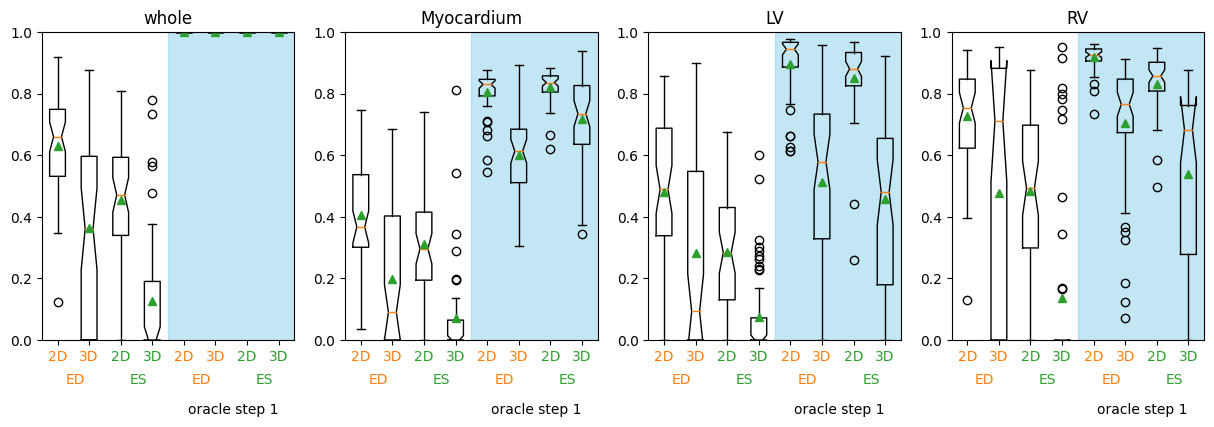

# Find best parameters

## 2D

In [ ]:
' Boxplots scores - 2D '

def OpenModel():
    # Find last updated file
    if not oracle: filename = 'results/cardiac_'+modality+'_'+repr(dimension)+'D_scores_'
    elif oracle:   filename = 'results/cardiac_'+modality+'_'+repr(dimension)+'D_oracle_scores_'
    files = glob.glob(filename+'*')
    files = [file for file in files if file[0:len(filename)+len(str(parameters))]==filename+str(parameters)]
    files_length = [int(file[len(filename)+len(str(parameters))+4:-4]) for file in files]
    if len(files) is not 0:
        ind = np.argmax(files_length)
        file, i_min = files[ind], files_length[ind]+1
        print('Found file', file, '- i_min =', i_min)
        return pd.read_csv(file)
    else: 
        print('Error! No files found.', filename)
        return None
    
modality, dimension, oracle = 'ED', 2, False

for modality in ['ED','ES']:
    DATAFRAMES = []

    # Parameters 1
    sigma = 1                      # Preprocess, Gaussian blur
    radius_ball = 0                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 20           # Step 1, number of H2 bars to consider
    thresh_small_LV = 0          # Step 1, minimal width of LV 
    ratio_small_RV = 0            # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = np.inf               # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 5          # Step 1, fill gap between LV and RV
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]
    DATAFRAMES.append( OpenModel() )

    # Parameters 2
    sigma = 1                      # Preprocess, Gaussian blur
    radius_ball = 0                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 10           # Step 1, number of H2 bars to consider
    thresh_small_LV = 200          # Step 1, minimal width of LV 
    ratio_small_RV = .1            # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = 5               # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 2          # Step 1, fill gap between LV and RV
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]
    DATAFRAMES.append( OpenModel() )

    # Parameters 3
    sigma = 0.5                      # Preprocess, Gaussian blur
    radius_ball = 0                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 20           # Step 1, number of H2 bars to consider
    thresh_small_LV = 0          # Step 1, minimal width of LV 
    ratio_small_RV = 0            # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = np.inf               # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 5          # Step 1, fill gap between LV and RV
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]
    DATAFRAMES.append( OpenModel() )

    # Parameters 4
    sigma = 1.5                      # Preprocess, Gaussian blur
    radius_ball = 0                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 20           # Step 1, number of H2 bars to consider
    thresh_small_LV = 0          # Step 1, minimal width of LV 
    ratio_small_RV = 0            # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = np.inf               # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 5          # Step 1, fill gap between LV and RV
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]
    DATAFRAMES.append( OpenModel() )

    # Parameters 5
    sigma = 1.5                      # Preprocess, Gaussian blur
    radius_ball = 0                # Preprocess, dilation parameter
    dt_threshold = 1             # Step 1, threshold for suggest_t
    H0_features_max = 10           # Step 1, number of H2 bars to consider
    thresh_small_LV = 200          # Step 1, minimal width of LV 
    ratio_small_RV = .1            # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = 5               # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 2          # Step 1, fill gap between LV and RV
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]
    DATAFRAMES.append( OpenModel() )
    
    # Parameters 6
    sigma = 1.5                      # Preprocess, Gaussian blur
    radius_ball = 0                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 20           # Step 1, number of H2 bars to consider
    thresh_small_LV = 0          # Step 1, minimal width of LV 
    ratio_small_RV = 0            # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = np.inf               # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 2          # Step 1, fill gap between LV and RV
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]
    DATAFRAMES.append( OpenModel() )

    # Parameters 7
    sigma = 2                      # Preprocess, Gaussian blur
    radius_ball = 0                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 20           # Step 1, number of H2 bars to consider
    thresh_small_LV = 0          # Step 1, minimal width of LV 
    ratio_small_RV = 0            # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = np.inf               # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 2          # Step 1, fill gap between LV and RV
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]
    DATAFRAMES.append( OpenModel() )


    ' Plot '

    fig, axs = plt.subplots(ncols=4, nrows=1, figsize=(15, 4))
    segmentation_labels = ['whole','Myocardium','LV','RV']
    for label_i, label in enumerate(segmentation_labels):    
        segs = [[df.iloc[i][label] for i in range(len(df))] for df in DATAFRAMES]

        axs[label_i].boxplot(segs, notch=True, showmeans=True);
        axs[label_i].set_title(label)
        axs[label_i].set_ylim(0,1); 
#         axs[label_i].set_xlim(0.5,8.5)
        axs[label_i].set_xticklabels(['P'+repr(i+1) for i in range(len(DATAFRAMES))])
    #     for xtick, color in zip(axs[label_i].get_xticklabels(), ['C1','C1','C2','C2']*2): xtick.set_color(color)
        axs[label_i].set_yticks([0,0.2,0.4,0.6,0.8,1])

    #     axs[label_i].add_patch(matplotlib.patches.Rectangle((4.5, 0), 4.5, 1,color='skyblue',alpha=0.5))
    #     for x in [1.55,5.55]: axs[label_i].text(x, -0.15, 'ED', horizontalalignment='center', verticalalignment='bottom',color='C1')
    #     for x in [3.55,7.55]: axs[label_i].text(x, -0.15, 'ES', horizontalalignment='center', verticalalignment='bottom',color='C2')
    #     axs[label_i].text(6.55, -0.25, 'oracle step 1', horizontalalignment='center', verticalalignment='bottom')

    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.2, hspace=0)
    # plt.savefig("results/scores_ACDC_article.pdf", format="pdf", bbox_inches="tight");

In [ ]:
' Batch - 2D '

# Parameters
sigma = 2                      # Preprocess, Gaussian blur
radius_ball = 0                # Preprocess, dilation parameter
dt_threshold = 1.0             # Step 1, threshold for suggest_t
H0_features_max = 20           # Step 1, number of H2 bars to consider
thresh_small_LV = 0          # Step 1, minimal width of LV 
ratio_small_RV = 0            # Step 1, minimal width of RV, compared to LV
ratio_big_RV = np.inf               # Step 1, maximal width of RV, compared to LV
add_to_iterations = 2          # Step 1, fill gap between LV and RV
parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]

MODELS = [('ED',2,False),('ES',2,False)]
for modality, dimension, oracle in MODELS:

    verbose, plot, plot_slice = False, False, False

    # Find last updated file
    if not oracle: filename = 'results/cardiac_'+modality+'_'+repr(dimension)+'D_scores_'
    elif oracle:   filename = 'results/cardiac_'+modality+'_'+repr(dimension)+'D_oracle_scores_'
    files = glob.glob(filename+'*')
    files = [file for file in files if file[0:len(filename)+len(str(parameters))]==filename+str(parameters)]
    files_length = [int(file[len(filename)+len(str(parameters))+4:-4]) for file in files]
    if len(files) is not 0:
        ind = np.argmax(files_length)
        file, i_min = files[ind], files_length[ind]+101
        print('Found file', file, '- i_min =', i_min)
        if i_min>150: continue
    else: 
        i_min = 101
        print('No files found!', filename)

    DICEs = dict()
    msg = 'Compute DICEs... '
    start_time = ChronometerStart(msg)
    for n_image in range(i_min,150+1):
        # Open image
        img, seg_medecin = OpenACDC(n_image, end=modality)
        if sigma>0:       img = scipy.ndimage.gaussian_filter(img, sigma=sigma)  
        if radius_ball>0: img = skimage.morphology.dilation(img, footprint=skimage.morphology.ball(radius_ball), out=None, shift_x=False, shift_y=False)

            
        if dimension == 2:
            # Segment slice by slice
            seg_final = np.zeros(np.shape(img))
            for z_pos in range(1,np.shape(img)[2]):
            # for z_pos in [9]:
                img_slice, seg_medecin_slice = img[:,:,z_pos], seg_medecin[:,:,z_pos]

                if not oracle: 
                    seg_union_slice   = Step1(img=img_slice,seg_medecin=seg_medecin_slice,\
                                              H0_features_max=H0_features_max,dt_threshold=dt_threshold,\
                                              thresh_small_LV=thresh_small_LV,ratio_small_RV=ratio_small_RV,\
                                              ratio_big_RV=ratio_big_RV,radius_ball=radius_ball,\
                                              add_to_iterations=add_to_iterations,verbose=verbose,plot=plot)
                elif oracle: seg_union_slice = (seg_medecin_slice>0)*1
                seg_contour_slice = Step2(img_slice,seg_union_slice,verbose=verbose,plot=plot)
                seg_final_slice   = Step3(seg_union_slice, seg_contour_slice,verbose=verbose)

                seg_final[:,:,z_pos] = seg_final_slice

        if dimension == 3:
            # Segment in one pass
            if not oracle: 
                seg_union   = Step1(img=img,seg_medecin=seg_medecin,\
                                    H0_features_max=H0_features_max,dt_threshold=dt_threshold,\
                                    thresh_small_LV=thresh_small_LV,ratio_small_RV=ratio_small_RV,\
                                    ratio_big_RV=ratio_big_RV,radius_ball=radius_ball,\
                                    add_to_iterations=add_to_iterations,verbose=verbose,plot=plot)
            elif oracle: seg_union = (seg_medecin>0)*1
            seg_contour = Step2(img,seg_union,verbose=verbose,plot=plot)
            seg_final   = Step3(seg_union, seg_contour,verbose=verbose)

        # Save dice
        DICEs[n_image] = GetDICEs(seg_final[:,:,1:-1],seg_medecin[:,:,1:-1],verbose=False)
        DICEs[n_image]['index'] = n_image
        ChronometerTick(start_time, n_image-i_min, 150+1-i_min, msg)

    # Save
    df = pd.DataFrame.from_dict(DICEs, orient='index')
    df = df.rename(columns={0: "whole", 1: "LV", 2: "Myocardium", 3: "RV"}, errors="raise")
    if i_min>101:
        df_old = pd.read_csv(file)
        df = pd.concat([df_old[['index','LV','Myocardium','RV','whole']],df[['index','LV','Myocardium','RV','whole']] ])
    df.to_csv(filename+str(parameters)+'_len'+repr(len(df))+'.csv')

In [ ]:
    # Save
    df = pd.DataFrame.from_dict(DICEs, orient='index')
    df = df.rename(columns={0: "whole", 1: "LV", 2: "Myocardium", 3: "RV"}, errors="raise")
    if i_min>101:
        df_old = pd.read_csv(file)
        df = pd.concat([df_old[['index','LV','Myocardium','RV','whole']],df[['index','LV','Myocardium','RV','whole']] ])
    df.to_csv(filename+str(parameters)+'_len'+repr(len(df))+'.csv')

## 3D

In [ ]:
' Boxplots scores - 3D '

def OpenModel():
    # Find last updated file
    if not oracle: filename = 'results/cardiac_'+modality+'_'+repr(dimension)+'D_scores_'
    elif oracle:   filename = 'results/cardiac_'+modality+'_'+repr(dimension)+'D_oracle_scores_'
    files = glob.glob(filename+'*')
    files = [file for file in files if file[0:len(filename)+len(str(parameters))]==filename+str(parameters)]
    files_length = [int(file[len(filename)+len(str(parameters))+4:-4]) for file in files]
    if len(files) is not 0:
        ind = np.argmax(files_length)
        file, i_min = files[ind], files_length[ind]+1
        print('Found file', file, '- i_min =', i_min)
        return pd.read_csv(file)
    else: 
        print('Error! No files found.', filename)
        return None
    
modality, dimension, oracle = 'ED', 3, False

for modality in ['ED','ES']:
    DATAFRAMES = []

    # Parameters 1
    sigma = 1                      # Preprocess, Gaussian blur
    radius_ball = 0                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 20           # Step 1, number of H2 bars to consider
    thresh_small_LV = 0          # Step 1, minimal width of LV 
    ratio_small_RV = 0            # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = np.inf               # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 5          # Step 1, fill gap between LV and RV
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]
    df = OpenModel()
    if df is not None: DATAFRAMES.append( df )

    # Parameters 2
    sigma = 1                      # Preprocess, Gaussian blur
    radius_ball = 0                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 10           # Step 1, number of H2 bars to consider
    thresh_small_LV = 200          # Step 1, minimal width of LV 
    ratio_small_RV = .1            # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = 5               # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 2          # Step 1, fill gap between LV and RV
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]
    df = OpenModel()
    if df is not None: DATAFRAMES.append( df )

    # Parameters 3
    sigma = 0.5                      # Preprocess, Gaussian blur
    radius_ball = 0                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 20           # Step 1, number of H2 bars to consider
    thresh_small_LV = 0          # Step 1, minimal width of LV 
    ratio_small_RV = 0            # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = np.inf               # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 5          # Step 1, fill gap between LV and RV
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]
    df = OpenModel()
    if df is not None: DATAFRAMES.append( df )

    # Parameters 4
    sigma = 1.5                      # Preprocess, Gaussian blur
    radius_ball = 0                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 20           # Step 1, number of H2 bars to consider
    thresh_small_LV = 0          # Step 1, minimal width of LV 
    ratio_small_RV = 0            # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = np.inf               # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 5          # Step 1, fill gap between LV and RV
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]
    df = OpenModel()
    if df is not None: DATAFRAMES.append( df )

    # Parameters 5
    sigma = 1.5                      # Preprocess, Gaussian blur
    radius_ball = 0                # Preprocess, dilation parameter
    dt_threshold = 1             # Step 1, threshold for suggest_t
    H0_features_max = 10           # Step 1, number of H2 bars to consider
    thresh_small_LV = 200          # Step 1, minimal width of LV 
    ratio_small_RV = .1            # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = 5               # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 2          # Step 1, fill gap between LV and RV
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]
    df = OpenModel()
    if df is not None: DATAFRAMES.append( df )
    
    # Parameters 6
    sigma = 1.5                      # Preprocess, Gaussian blur
    radius_ball = 0                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 20           # Step 1, number of H2 bars to consider
    thresh_small_LV = 0          # Step 1, minimal width of LV 
    ratio_small_RV = 0            # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = np.inf               # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 2          # Step 1, fill gap between LV and RV
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]
    df = OpenModel()
    if df is not None: DATAFRAMES.append( df )

    # Parameters 7
    sigma = 2                      # Preprocess, Gaussian blur
    radius_ball = 0                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 20           # Step 1, number of H2 bars to consider
    thresh_small_LV = 0          # Step 1, minimal width of LV 
    ratio_small_RV = 0            # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = np.inf               # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 2          # Step 1, fill gap between LV and RV
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]
    df = OpenModel()
    if df is not None: DATAFRAMES.append( df )
        
    # Parameters 8
    sigma = 2.5                      # Preprocess, Gaussian blur
    radius_ball = 0                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 20           # Step 1, number of H2 bars to consider
    thresh_small_LV = 0          # Step 1, minimal width of LV 
    ratio_small_RV = 0            # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = np.inf               # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 2          # Step 1, fill gap between LV and RV
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]
    df = OpenModel()
    if df is not None: DATAFRAMES.append( df )

    # Parameters 9
    sigma = 3                      # Preprocess, Gaussian blur
    radius_ball = 0                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 20           # Step 1, number of H2 bars to consider
    thresh_small_LV = 0          # Step 1, minimal width of LV 
    ratio_small_RV = 0            # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = np.inf               # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 2          # Step 1, fill gap between LV and RV
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]
    df = OpenModel()
    if df is not None: DATAFRAMES.append( df )

    # Parameters 10
    sigma = 2.5                      # Preprocess, Gaussian blur
    radius_ball = 0                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 15           # Step 1, number of H2 bars to consider
    thresh_small_LV = 0          # Step 1, minimal width of LV 
    ratio_small_RV = 0            # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = np.inf               # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 2          # Step 1, fill gap between LV and RV
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]
    df = OpenModel()
    if df is not None: DATAFRAMES.append( df )

    # Parameters 11
    sigma = 2                      # Preprocess, Gaussian blur
    radius_ball = 0                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 20           # Step 1, number of H2 bars to consider
    thresh_small_LV = 0          # Step 1, minimal width of LV 
    ratio_small_RV = 0            # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = np.inf               # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 5          # Step 1, fill gap between LV and RV
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]
    df = OpenModel()
    if df is not None: DATAFRAMES.append( df )        
        
    # Parameters 12
    sigma = 2.5                      # Preprocess, Gaussian blur
    radius_ball = 0                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 10           # Step 1, number of H2 bars to consider
    thresh_small_LV = 0          # Step 1, minimal width of LV 
    ratio_small_RV = 0            # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = np.inf               # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 2          # Step 1, fill gap between LV and RV
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]
    df = OpenModel()
    if df is not None: DATAFRAMES.append( df )        
        
    # Parameters 13
    sigma = 2.5                      # Preprocess, Gaussian blur
    radius_ball = 0                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 5           # Step 1, number of H2 bars to consider
    thresh_small_LV = 0          # Step 1, minimal width of LV 
    ratio_small_RV = 0            # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = np.inf               # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 2          # Step 1, fill gap between LV and RV
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]
    df = OpenModel()
    if df is not None: DATAFRAMES.append( df )        


    ' Plot '

    fig, axs = plt.subplots(ncols=4, nrows=1, figsize=(15, 4))
    segmentation_labels = ['whole','Myocardium','LV','RV']
    for label_i, label in enumerate(segmentation_labels):    
        segs = [[df.iloc[i][label] for i in range(len(df))] for df in DATAFRAMES]

        axs[label_i].boxplot(segs, notch=True, showmeans=True);
        axs[label_i].set_title(label)
        axs[label_i].set_ylim(0,1); 
#         axs[label_i].set_xlim(0.5,8.5)
        axs[label_i].set_xticklabels(['P'+repr(i+1) for i in range(len(DATAFRAMES))])
    #     for xtick, color in zip(axs[label_i].get_xticklabels(), ['C1','C1','C2','C2']*2): xtick.set_color(color)
        axs[label_i].set_yticks([0,0.2,0.4,0.6,0.8,1])

    #     axs[label_i].add_patch(matplotlib.patches.Rectangle((4.5, 0), 4.5, 1,color='skyblue',alpha=0.5))
    #     for x in [1.55,5.55]: axs[label_i].text(x, -0.15, 'ED', horizontalalignment='center', verticalalignment='bottom',color='C1')
    #     for x in [3.55,7.55]: axs[label_i].text(x, -0.15, 'ES', horizontalalignment='center', verticalalignment='bottom',color='C2')
    #     axs[label_i].text(6.55, -0.25, 'oracle step 1', horizontalalignment='center', verticalalignment='bottom')

    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.2, hspace=0)
    # plt.savefig("results/scores_ACDC_article.pdf", format="pdf", bbox_inches="tight");

In [ ]:
' Boxplots scores - 3D - test radius_ball '

def OpenModel():
    # Find last updated file
    if not oracle: filename = 'results/cardiac_'+modality+'_'+repr(dimension)+'D_scores_'
    elif oracle:   filename = 'results/cardiac_'+modality+'_'+repr(dimension)+'D_oracle_scores_'
    files = glob.glob(filename+'*')
    files = [file for file in files if file[0:len(filename)+len(str(parameters))]==filename+str(parameters)]
    files_length = [int(file[len(filename)+len(str(parameters))+4:-4]) for file in files]
    if len(files) is not 0:
        ind = np.argmax(files_length)
        file, i_min = files[ind], files_length[ind]+1
        print('Found file', file, '- i_min =', i_min)
        return pd.read_csv(file)
    else: 
        print('Error! No files found.', filename)
        return None
    
modality, dimension, oracle = 'ED', 3, False

for modality in ['ED','ES']:
    DATAFRAMES = []

    # Parameters 13
    sigma = 2.5                      # Preprocess, Gaussian blur
    radius_ball = 0                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 10           # Step 1, number of H2 bars to consider
    thresh_small_LV = 0          # Step 1, minimal width of LV 
    ratio_small_RV = 0            # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = np.inf               # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 2          # Step 1, fill gap between LV and RV
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]
    df = OpenModel()
    if df is not None: DATAFRAMES.append( df )     
        
    # Parameters 19
    sigma = 2.5                      # Preprocess, Gaussian blur
    radius_ball = 1                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 10           # Step 1, number of H2 bars to consider
    thresh_small_LV = 0          # Step 1, minimal width of LV 
    ratio_small_RV = 0            # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = np.inf               # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 2          # Step 1, fill gap between LV and RV
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]
    df = OpenModel()
    if df is not None: DATAFRAMES.append( df )     

    # Parameters 20
    sigma = 2.5                      # Preprocess, Gaussian blur
    radius_ball = 2                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 10           # Step 1, number of H2 bars to consider
    thresh_small_LV = 0          # Step 1, minimal width of LV 
    ratio_small_RV = 0            # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = np.inf               # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 2          # Step 1, fill gap between LV and RV
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]
    df = OpenModel()
    if df is not None: DATAFRAMES.append( df )     

    # Parameters 21
    sigma = 2.5                      # Preprocess, Gaussian blur
    radius_ball = 3                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 10           # Step 1, number of H2 bars to consider
    thresh_small_LV = 0          # Step 1, minimal width of LV 
    ratio_small_RV = 0            # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = np.inf               # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 2          # Step 1, fill gap between LV and RV
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]
    df = OpenModel()
    if df is not None: DATAFRAMES.append( df )     

    # Parameters 22
    sigma = 2.5                      # Preprocess, Gaussian blur
    radius_ball = 4                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 10           # Step 1, number of H2 bars to consider
    thresh_small_LV = 0          # Step 1, minimal width of LV 
    ratio_small_RV = 0            # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = np.inf               # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 2          # Step 1, fill gap between LV and RV
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]
    df = OpenModel()
    if df is not None: DATAFRAMES.append( df )     

    # Parameters 23
    sigma = 2.5                      # Preprocess, Gaussian blur
    radius_ball = 5                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 10           # Step 1, number of H2 bars to consider
    thresh_small_LV = 0          # Step 1, minimal width of LV 
    ratio_small_RV = 0            # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = np.inf               # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 2          # Step 1, fill gap between LV and RV
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]
    df = OpenModel()
    if df is not None: DATAFRAMES.append( df )    
        
    ' Plot '

    fig, axs = plt.subplots(ncols=4, nrows=1, figsize=(15, 4))
    segmentation_labels = ['whole','Myocardium','LV','RV']
    for label_i, label in enumerate(segmentation_labels):    
        segs = [[df.iloc[i][label] for i in range(len(df))] for df in DATAFRAMES]

        axs[label_i].boxplot(segs, notch=True, showmeans=True);
        axs[label_i].set_title(label)
        axs[label_i].set_ylim(0,1); 
#         axs[label_i].set_xlim(0.5,8.5)
        axs[label_i].set_xticklabels(['P'+repr(i+1) for i in range(len(DATAFRAMES))])
    #     for xtick, color in zip(axs[label_i].get_xticklabels(), ['C1','C1','C2','C2']*2): xtick.set_color(color)
        axs[label_i].set_yticks([0,0.2,0.4,0.6,0.8,1])

    #     axs[label_i].add_patch(matplotlib.patches.Rectangle((4.5, 0), 4.5, 1,color='skyblue',alpha=0.5))
    #     for x in [1.55,5.55]: axs[label_i].text(x, -0.15, 'ED', horizontalalignment='center', verticalalignment='bottom',color='C1')
    #     for x in [3.55,7.55]: axs[label_i].text(x, -0.15, 'ES', horizontalalignment='center', verticalalignment='bottom',color='C2')
    #     axs[label_i].text(6.55, -0.25, 'oracle step 1', horizontalalignment='center', verticalalignment='bottom')

    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.2, hspace=0)
    # plt.savefig("results/scores_ACDC_article.pdf", format="pdf", bbox_inches="tight");

In [ ]:
' Batch - 3D '

MODELS = [('ED',3,False),('ES',3,False)]

def BatchComputeScores():
    for modality, dimension, oracle in MODELS:

        verbose, plot, plot_slice = False, False, False

        # Find last updated file
        if not oracle: filename = 'results/cardiac_'+modality+'_'+repr(dimension)+'D_scores_'
        elif oracle:   filename = 'results/cardiac_'+modality+'_'+repr(dimension)+'D_oracle_scores_'
        files = glob.glob(filename+'*')
        files = [file for file in files if file[0:len(filename)+len(str(parameters))]==filename+str(parameters)]
        files_length = [int(file[len(filename)+len(str(parameters))+4:-4]) for file in files]
        if len(files) is not 0:
            ind = np.argmax(files_length)
            file, i_min = files[ind], files_length[ind]+101
            print('Found file', file, '- i_min =', i_min)
            if i_min>150: continue
        else: 
            i_min = 101
            print('No files found!', filename)

        DICEs = dict()
        msg = 'Compute DICEs... '
        start_time = ChronometerStart(msg)
        for n_image in range(i_min,150+1):
            # Open image
            img, seg_medecin = OpenACDC(n_image, end=modality)
            if sigma>0:       img = scipy.ndimage.gaussian_filter(img, sigma=sigma)  
#             if radius_ball>0: img = skimage.morphology.dilation(img, footprint=skimage.morphology.ball(radius_ball), out=None, shift_x=False, shift_y=False)

            if dimension == 2:
                # Segment slice by slice
                seg_final = np.zeros(np.shape(img))
                for z_pos in range(1,np.shape(img)[2]):
                # for z_pos in [9]:
                    img_slice, seg_medecin_slice = img[:,:,z_pos], seg_medecin[:,:,z_pos]

                    if not oracle: 
                        seg_union_slice   = Step1(img=img_slice,seg_medecin=seg_medecin_slice,\
                                                  H0_features_max=H0_features_max,dt_threshold=dt_threshold,\
                                                  thresh_small_LV=thresh_small_LV,ratio_small_RV=ratio_small_RV,\
                                                  ratio_big_RV=ratio_big_RV,radius_ball=radius_ball,\
                                                  add_to_iterations=add_to_iterations,verbose=verbose,plot=plot)
                    elif oracle: seg_union_slice = (seg_medecin_slice>0)*1
                    seg_contour_slice = Step2(img_slice,seg_union_slice,verbose=verbose,plot=plot)
                    seg_final_slice   = Step3(seg_union_slice, seg_contour_slice,verbose=verbose)

                    seg_final[:,:,z_pos] = seg_final_slice

            if dimension == 3:
                # Segment in one pass
                if not oracle: 
                    seg_union   = Step1(img=img,seg_medecin=seg_medecin,\
                                        H0_features_max=H0_features_max,dt_threshold=dt_threshold,\
                                        thresh_small_LV=thresh_small_LV,ratio_small_RV=ratio_small_RV,\
                                        ratio_big_RV=ratio_big_RV,radius_ball=radius_ball,\
                                        add_to_iterations=add_to_iterations,verbose=verbose,plot=plot)
                elif oracle: seg_union = (seg_medecin>0)*1
                    
                # Step 2
                if radius_ball>0: # Erode slice by slice
                    for z in range(np.shape(img)[2]):
                        img[:,:,z] = skimage.morphology.binary_erosion(img[:,:,z], footprint=skimage.morphology.disk(radius_ball))

                seg_contour = Step2(img,seg_union,verbose=verbose,plot=plot)
                seg_final   = Step3(seg_union, seg_contour,verbose=verbose)

            # Save dice
            DICEs[n_image] = GetDICEs(seg_final[:,:,1:-1],seg_medecin[:,:,1:-1],verbose=False)
            DICEs[n_image]['index'] = n_image
            ChronometerTick(start_time, n_image-i_min, 150+1-i_min, msg)

        # Save
        df = pd.DataFrame.from_dict(DICEs, orient='index')
        df = df.rename(columns={0: "whole", 1: "LV", 2: "Myocardium", 3: "RV"}, errors="raise")
        if i_min>101:
            df_old = pd.read_csv(file)
            df = pd.concat([df_old[['index','LV','Myocardium','RV','whole']],df[['index','LV','Myocardium','RV','whole']] ])
        df.to_csv(filename+str(parameters)+'_len'+repr(len(df))+'.csv')


' Compute scores'
    
# Parameters 19
sigma = 2.5                      # Preprocess, Gaussian blur
radius_ball = 1                # Preprocess, dilation parameter
dt_threshold = 1.0             # Step 1, threshold for suggest_t
H0_features_max = 10           # Step 1, number of H2 bars to consider
thresh_small_LV = 0          # Step 1, minimal width of LV 
ratio_small_RV = 0            # Step 1, minimal width of RV, compared to LV
ratio_big_RV = np.inf               # Step 1, maximal width of RV, compared to LV
add_to_iterations = 2          # Step 1, fill gap between LV and RV
parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]
BatchComputeScores()

# Parameters 20
sigma = 2.5                      # Preprocess, Gaussian blur
radius_ball = 2                # Preprocess, dilation parameter
dt_threshold = 1.0             # Step 1, threshold for suggest_t
H0_features_max = 10           # Step 1, number of H2 bars to consider
thresh_small_LV = 0          # Step 1, minimal width of LV 
ratio_small_RV = 0            # Step 1, minimal width of RV, compared to LV
ratio_big_RV = np.inf               # Step 1, maximal width of RV, compared to LV
add_to_iterations = 2          # Step 1, fill gap between LV and RV
parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]
BatchComputeScores()

# Parameters 21
sigma = 2.5                      # Preprocess, Gaussian blur
radius_ball = 3                # Preprocess, dilation parameter
dt_threshold = 1.0             # Step 1, threshold for suggest_t
H0_features_max = 10           # Step 1, number of H2 bars to consider
thresh_small_LV = 0          # Step 1, minimal width of LV 
ratio_small_RV = 0            # Step 1, minimal width of RV, compared to LV
ratio_big_RV = np.inf               # Step 1, maximal width of RV, compared to LV
add_to_iterations = 2          # Step 1, fill gap between LV and RV
parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]
BatchComputeScores()

# Parameters 22
sigma = 2.5                      # Preprocess, Gaussian blur
radius_ball = 4                # Preprocess, dilation parameter
dt_threshold = 1.0             # Step 1, threshold for suggest_t
H0_features_max = 10           # Step 1, number of H2 bars to consider
thresh_small_LV = 0          # Step 1, minimal width of LV 
ratio_small_RV = 0            # Step 1, minimal width of RV, compared to LV
ratio_big_RV = np.inf               # Step 1, maximal width of RV, compared to LV
add_to_iterations = 2          # Step 1, fill gap between LV and RV
parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]
BatchComputeScores()

# Parameters 23
sigma = 2.5                      # Preprocess, Gaussian blur
radius_ball = 5                # Preprocess, dilation parameter
dt_threshold = 1.0             # Step 1, threshold for suggest_t
H0_features_max = 10           # Step 1, number of H2 bars to consider
thresh_small_LV = 0          # Step 1, minimal width of LV 
ratio_small_RV = 0            # Step 1, minimal width of RV, compared to LV
ratio_big_RV = np.inf               # Step 1, maximal width of RV, compared to LV
add_to_iterations = 2          # Step 1, fill gap between LV and RV
parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]
BatchComputeScores()

## Bloxplots scores for article - 20231217

In [ ]:
' Boxplots scores '

DATAFRAMES = []

# Parameters 5
sigma = 1.5                      # Preprocess, Gaussian blur
radius_ball = 0                # Preprocess, dilation parameter
dt_threshold = 1             # Step 1, threshold for suggest_t
H0_features_max = 10           # Step 1, number of H2 bars to consider
thresh_small_LV = 200          # Step 1, minimal width of LV 
ratio_small_RV = .1            # Step 1, minimal width of RV, compared to LV
ratio_big_RV = 5               # Step 1, maximal width of RV, compared to LV
add_to_iterations = 2          # Step 1, fill gap between LV and RV
parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]
modality, dimension, oracle = 'ED',2,False
DATAFRAMES.append( OpenModel() )

# Parameters 4
sigma = 1.5                      # Preprocess, Gaussian blur
radius_ball = 0                # Preprocess, dilation parameter
dt_threshold = 1.0             # Step 1, threshold for suggest_t
H0_features_max = 20           # Step 1, number of H2 bars to consider
thresh_small_LV = 0          # Step 1, minimal width of LV 
ratio_small_RV = 0            # Step 1, minimal width of RV, compared to LV
ratio_big_RV = np.inf               # Step 1, maximal width of RV, compared to LV
add_to_iterations = 5          # Step 1, fill gap between LV and RV
parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]
modality, dimension, oracle = 'ES',2,False
DATAFRAMES.append( OpenModel() )

# Parameters 13
sigma = 2.5                      # Preprocess, Gaussian blur
radius_ball = 0                # Preprocess, dilation parameter
dt_threshold = 1.0             # Step 1, threshold for suggest_t
# H0_features_max = 5           # Step 1, number of H2 bars to consider
H0_features_max = 10           # Step 1, number of H2 bars to consider
thresh_small_LV = 0          # Step 1, minimal width of LV 
ratio_small_RV = 0            # Step 1, minimal width of RV, compared to LV
ratio_big_RV = np.inf               # Step 1, maximal width of RV, compared to LV
add_to_iterations = 2          # Step 1, fill gap between LV and RV
parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]
modality, dimension, oracle = 'ED',3,False
DATAFRAMES.append( OpenModel() )

# Parameters 13
modality, dimension, oracle = 'ES',3,False
DATAFRAMES.append( OpenModel() )

# Parameters oracle
sigma = 1                      # Preprocess, Gaussian blur
radius_ball = 0                # Preprocess, dilation parameter
dt_threshold = 1.0             # Step 1, threshold for suggest_t
H0_features_max = 20           # Step 1, number of H2 bars to consider
thresh_small_LV = 0          # Step 1, minimal width of LV 
ratio_small_RV = 0            # Step 1, minimal width of RV, compared to LV
ratio_big_RV = np.inf               # Step 1, maximal width of RV, compared to LV
add_to_iterations = 5          # Step 1, fill gap between LV and RV
parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]

# MODELS = [('ED',2,False),('ED',3,False),('ES',2,False),('ES',3,False),('ED',2,True), ('ED',3,True), ('ES',2,True), ('ES',3,True)]
MODELS_oracle = [('ED',2,True), ('ED',3,True), ('ES',2,True), ('ES',3,True)]
for modality, dimension, oracle in MODELS_oracle:
    # Find last updated file
    if not oracle: filename = 'results/cardiac_'+modality+'_'+repr(dimension)+'D_scores_'
    elif oracle:   filename = 'results/cardiac_'+modality+'_'+repr(dimension)+'D_oracle_scores_'
    files = glob.glob(filename+'*')
    files = [file for file in files if file[0:len(filename)+len(str(parameters))]==filename+str(parameters)]
    files_length = [int(file[len(filename)+len(str(parameters))+4:-4]) for file in files]
    if len(files) is not 0:
        ind = np.argmax(files_length)
        file, i_min = files[ind], files_length[ind]+1
        print('Found file', file, '- i_min =', i_min)
        DATAFRAMES.append( pd.read_csv(file) )
    else: print('Error! No files found.', filename)
    
' Plot '

fig, axs = plt.subplots(ncols=4, nrows=1, figsize=(15, 4))
segmentation_labels = ['whole','Myocardium','LV','RV']
for label_i, label in enumerate(segmentation_labels):    
    segs = [[df.iloc[i][label] for i in range(len(df))] for df in DATAFRAMES]
    segs = [segs[0],segs[2],segs[1],segs[3],segs[4],segs[6],segs[5],segs[7]]
    
    axs[label_i].boxplot(segs, notch=True, showmeans=True);
    axs[label_i].set_title(label)
    axs[label_i].set_ylim(0,1); 
    axs[label_i].set_xlim(0.5,8.5)
    axs[label_i].set_xticklabels(['2D','3D']*4)
    for xtick, color in zip(axs[label_i].get_xticklabels(), ['C1','C1','C2','C2']*2): xtick.set_color(color)
    axs[label_i].set_yticks([0,0.2,0.4,0.6,0.8,1])
    
    axs[label_i].add_patch(matplotlib.patches.Rectangle((4.5, 0), 4.5, 1,color='skyblue',alpha=0.5))
    for x in [1.55,5.55]: axs[label_i].text(x, -0.15, 'ED', horizontalalignment='center', verticalalignment='bottom',color='C1')
    for x in [3.55,7.55]: axs[label_i].text(x, -0.15, 'ES', horizontalalignment='center', verticalalignment='bottom',color='C2')
    axs[label_i].text(6.55, -0.25, 'oracle step 1', horizontalalignment='center', verticalalignment='bottom')
    
    # Print scores
    for i_seg, seg in enumerate(segs):
        msg = '$'+repr(round(np.mean(seg),3))+"\\"+'pm'+repr(round(np.std(seg),3))+'$, median '+repr(round(np.median(seg),3))
        msg = repr(i_seg)+' '+msg        
        print(msg)
        
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.2, hspace=0)
plt.savefig("results/scores_ACDC_article.pdf", format="pdf", bbox_inches="tight");

## Bloxplots scores for article - 20231228

In [ ]:
' Boxplots scores '

DATAFRAMES = []

modality, dimension, oracle = 'ED',2,False
# # Parameters 5
# sigma = 1.5                      # Preprocess, Gaussian blur
# radius_ball = 0                # Preprocess, dilation parameter
# dt_threshold = 1             # Step 1, threshold for suggest_t
# H0_features_max = 10           # Step 1, number of H2 bars to consider
# thresh_small_LV = 200          # Step 1, minimal width of LV 
# ratio_small_RV = .1            # Step 1, minimal width of RV, compared to LV
# ratio_big_RV = 5               # Step 1, maximal width of RV, compared to LV
# add_to_iterations = 2          # Step 1, fill gap between LV and RV
# parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]
# Parameters - Step1_Hausdorff - 6
sigma = 0.0                      # Preprocess, Gaussian blur
radius_ball = 0                # Preprocess, dilation parameter
dt_threshold = 1.0             # Step 1, threshold for suggest_t
H0_features_max = 20           # Step 1, number of H2 bars to consider
thresh_small_LV = 500            # Step 1, minimal width of LV 
ratio_small_RV = 1/4             # Step 1, minimal width of RV, compared to LV
ratio_big_RV = 4          # Step 1, maximal width of RV, compared to LV
add_to_iterations = 2          # Step 1, fill gap between LV and RV
maximal_distance = 50          # Step 1, max Hausdorff distance between RV and LV
sigma_step1 = 1.5                # Step 1, Preprocess, Gaussian blur
radius_ball_erosion_step1 = 0  # Step 1, Preprocess, erosion parameter
parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,\
              add_to_iterations,maximal_distance,sigma_step1,radius_ball_erosion_step1]
DATAFRAMES.append( OpenModel() )

modality, dimension, oracle = 'ES',2,False
# Parameters 4
sigma = 1.5                      # Preprocess, Gaussian blur
radius_ball = 0                # Preprocess, dilation parameter
dt_threshold = 1.0             # Step 1, threshold for suggest_t
H0_features_max = 20           # Step 1, number of H2 bars to consider
thresh_small_LV = 0          # Step 1, minimal width of LV 
ratio_small_RV = 0            # Step 1, minimal width of RV, compared to LV
ratio_big_RV = np.inf               # Step 1, maximal width of RV, compared to LV
add_to_iterations = 5          # Step 1, fill gap between LV and RV
parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]
DATAFRAMES.append( OpenModel() )

modality, dimension, oracle = 'ED',3,False
# # Parameters 13
# sigma = 2.5                      # Preprocess, Gaussian blur
# radius_ball = 0                # Preprocess, dilation parameter
# dt_threshold = 1.0             # Step 1, threshold for suggest_t
# # H0_features_max = 5           # Step 1, number of H2 bars to consider
# H0_features_max = 10           # Step 1, number of H2 bars to consider
# thresh_small_LV = 0          # Step 1, minimal width of LV 
# ratio_small_RV = 0            # Step 1, minimal width of RV, compared to LV
# ratio_big_RV = np.inf               # Step 1, maximal width of RV, compared to LV
# add_to_iterations = 2          # Step 1, fill gap between LV and RV
# parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]
# Parameters NEW 2
sigma = 2.5                      # Preprocess, Gaussian blur
radius_ball = 0                # Preprocess, dilation parameter
dt_threshold = 1.0             # Step 1, threshold for suggest_t
H0_features_max = 10           # Step 1, number of H2 bars to consider
thresh_small_LV = 1000          # Step 1, minimal width of LV 
ratio_small_RV = 1/5            # Step 1, minimal width of RV, compared to LV
ratio_big_RV = 3               # Step 1, maximal width of RV, compared to LV
add_to_iterations = 2          # Step 1, fill gap between LV and RV
maximal_distance = 50          # Step 1, max Hausdorff distance between RV and LV
parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations,maximal_distance]
DATAFRAMES.append( OpenModel() )

modality, dimension, oracle = 'ES',3,False
# Parameters 13
sigma = 2.5                      # Preprocess, Gaussian blur
radius_ball = 0                # Preprocess, dilation parameter
dt_threshold = 1.0             # Step 1, threshold for suggest_t
H0_features_max = 5           # Step 1, number of H2 bars to consider
thresh_small_LV = 0          # Step 1, minimal width of LV 
ratio_small_RV = 0            # Step 1, minimal width of RV, compared to LV
ratio_big_RV = np.inf               # Step 1, maximal width of RV, compared to LV
add_to_iterations = 2          # Step 1, fill gap between LV and RV
parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]
DATAFRAMES.append( OpenModel() )

# Parameters oracle
sigma = 1                      # Preprocess, Gaussian blur
radius_ball = 0                # Preprocess, dilation parameter
dt_threshold = 1.0             # Step 1, threshold for suggest_t
H0_features_max = 20           # Step 1, number of H2 bars to consider
thresh_small_LV = 0          # Step 1, minimal width of LV 
ratio_small_RV = 0            # Step 1, minimal width of RV, compared to LV
ratio_big_RV = np.inf               # Step 1, maximal width of RV, compared to LV
add_to_iterations = 5          # Step 1, fill gap between LV and RV
parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]

# MODELS = [('ED',2,False),('ED',3,False),('ES',2,False),('ES',3,False),('ED',2,True), ('ED',3,True), ('ES',2,True), ('ES',3,True)]
MODELS_oracle = [('ED',2,True), ('ED',3,True), ('ES',2,True), ('ES',3,True)]
for modality, dimension, oracle in MODELS_oracle:
    # Find last updated file
    if not oracle: filename = 'results/cardiac_'+modality+'_'+repr(dimension)+'D_scores_'
    elif oracle:   filename = 'results/cardiac_'+modality+'_'+repr(dimension)+'D_oracle_scores_'
    files = glob.glob(filename+'*')
    files = [file for file in files if file[0:len(filename)+len(str(parameters))]==filename+str(parameters)]
    files_length = [int(file[len(filename)+len(str(parameters))+4:-4]) for file in files]
    if len(files) is not 0:
        ind = np.argmax(files_length)
        file, i_min = files[ind], files_length[ind]+1
        print('Found file', file, '- i_min =', i_min)
        DATAFRAMES.append( pd.read_csv(file) )
    else: print('Error! No files found.', filename)
    
' Plot '

fig, axs = plt.subplots(ncols=4, nrows=1, figsize=(15, 4))
segmentation_labels = ['whole','Myocardium','LV','RV']
for label_i, label in enumerate(segmentation_labels):    
    segs = [[df.iloc[i][label] for i in range(len(df))] for df in DATAFRAMES]
    segs = [segs[0],segs[2],segs[1],segs[3],segs[4],segs[6],segs[5],segs[7]]
    
    axs[label_i].boxplot(segs, notch=True, showmeans=True);
    axs[label_i].set_title(label)
    axs[label_i].set_ylim(0,1); 
    axs[label_i].set_xlim(0.5,8.5)
    axs[label_i].set_xticklabels(['2D','3D']*4)
    for xtick, color in zip(axs[label_i].get_xticklabels(), ['C1','C1','C2','C2']*2): xtick.set_color(color)
    axs[label_i].set_yticks([0,0.2,0.4,0.6,0.8,1])
    
    axs[label_i].add_patch(matplotlib.patches.Rectangle((4.5, 0), 4.5, 1,color='skyblue',alpha=0.5))
    for x in [1.55,5.55]: axs[label_i].text(x, -0.15, 'ED', horizontalalignment='center', verticalalignment='bottom',color='C1')
    for x in [3.55,7.55]: axs[label_i].text(x, -0.15, 'ES', horizontalalignment='center', verticalalignment='bottom',color='C2')
    axs[label_i].text(6.55, -0.25, 'oracle step 1', horizontalalignment='center', verticalalignment='bottom')
    
    # Print scores
    for i_seg, seg in enumerate(segs):
        msg = '$'+repr(round(np.mean(seg),3))+"\\"+'pm'+repr(round(np.std(seg),3))+'$, median '+repr(round(np.median(seg),3))
        msg = repr(i_seg)+' '+msg        
        print(msg)
        
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.2, hspace=0)
plt.savefig("results/scores_ACDC_article_20231228.pdf", format="pdf", bbox_inches="tight");

# Verify model

### Verify model - sphericity

In [ ]:
' Verify model - sphericity '
''' NOT FINISHED '''

# n_image = 10          # between 1 and 150 included
# modality = 'ED'      # can be 'ED or 'ES' (end diastole, end systole)

# verbose, plot, plot_slice = False, False, True
verbose, plot, plot_slice = True, True, True

# Parameters
sigma = 1                      # Preprocess, Gaussian blur
radius_ball = 0                # Preprocess, dilation parameter
dt_threshold = 1.0             # Step 1, threshold for suggest_t
H0_features_max = 10           # Step 1, number of H2 bars to consider
thresh_small_LV = 20            # Step 1, minimal width of LV 
ratio_small_RV = 0             # Step 1, minimal width of RV, compared to LV
ratio_big_RV = np.inf               # Step 1, maximal width of RV, compared to LV
add_to_iterations = 2          # Step 1, fill gap between LV and RV
# dilatation = 0

# dilatation_totest = range(0,0+1)
# dilatation_totest = range(0,2+1)
# dilatation_totest = range(0,3+1)
# NumberComponents3D = {dilatation:{modality:dict() for modality in ['ED','ES']} for dilatation in dilatation_totest}
# NumberComponents2D = {dilatation:{modality:dict() for modality in ['ED','ES']} for dilatation in dilatation_totest}

IndexLV = {modality:dict() for modality in ['ED','ES']}
IndexRV = {modality:dict() for modality in ['ED','ES']}

msg = 'Verify model... '
start_time = ChronometerStart(msg)
# for n_image in range(1,150+1):
for n_image in [6]:
    for modality in ['ED','ES']:
        # Open image
        img, seg_medecin = OpenACDC(n_image, end=modality)
        
        if sigma>0:       img = scipy.ndimage.gaussian_filter(img, sigma=sigma)  
        if radius_ball>0: img = skimage.morphology.dilation(img, footprint=skimage.morphology.ball(radius_ball), out=None, shift_x=False, shift_y=False)

        # Compute PH0
        if verbose: start_time = ChronometerStart('Compute diagram... ')
        barcode = cripser.computePH(1-img,maxdim=0) # Compute diagram
        H0 = [list(bar[1::]) for bar in barcode if bar[0]==0]
        H0 = [bar for _,bar in sorted(zip([bar[1]-bar[0] for bar in H0],H0))[::-1]] # Sort list H2 by persistence
        H0[0][1] = 1 # correction infinite bar (1 instead of inf)
        if verbose: ChronometerStop(start_time, method='s')

        # Compute sphericity
        H0_sphericity = dict()
        H0_CC = dict()
        if verbose: start_time = ChronometerStart('Compute sphericity... ')
        for i in range(H0_features_max):
            t_birth, pos = H0[i][0], [int(H0[i][2+k]) for k in range(img.ndim)]
            CC = suggest_t_pos(img,pos,t_birth,dt_threshold=dt_threshold,direction='left') # Segment via suggest_t_pos
            H0_CC[i] = CC
            H0_sphericity[i] =  ComputeSphericity(CC, verbose=False)                       # Compute sphericity  
        if verbose: ChronometerStop(start_time, method='s')
        if verbose: print('H0_sphericity', H0_sphericity)
            
        # Segment LV
        H0_sphericity_thresh = {i:H0_sphericity[i]*(np.sum(H0_CC[i])>=thresh_small_LV) for i in H0_sphericity}
            # Discard small components
        H0_sphericity_thresh = [H0_sphericity[i]*(np.sum(H0_CC[i])>=thresh_small_LV) for i in H0_sphericity]
        H0_sphericity_meanvalue = [np.mean(seg_medecin[np.where(H0_CC[i])]) for i in H0_sphericity]
        argsort = np.argsort(H0_sphericity_thresh)[::-1]
        print([H0_sphericity_meanvalue[i] for i in argsort])
            
#         best_i_LV = max(H0_sphericity_thresh, key=lambda k: H0_sphericity_thresh[k])
#         seg_LV = H0_CC[best_i_LV]
#         if radius_ball>0: seg_LV = skimage.morphology.binary_erosion(seg_LV, footprint=skimage.morphology.ball(radius_ball))
#         if verbose: print('Most spherical CC is index', best_i_LV, '- width', np.sum(seg_LV))

#         # Segment RV
#         top_features_loc = [np.mean(np.where(H0_CC[i]),axis=1) for i in range(H0_features_max)]
#         distances = np.linalg.norm(np.array(top_features_loc) - top_features_loc[best_i_LV],axis=1)
#         for i in range(H0_features_max): # Discard small or big components
#             if np.sum(H0_CC[i])<ratio_small_RV*np.sum(seg_LV) or np.sum(H0_CC[i])>ratio_big_RV*np.sum(seg_LV):
#                 distances[i] = np.inf
#         best_i_RV = np.argsort(distances)[1] # second smallest distance (the first one is 0)
#         seg_RV = H0_CC[best_i_RV]
#         if min(seg_LV[seg_RV>0])>0:
#             seg_LV[seg_RV>0]=0
#             if verbose: print('Warning! LV and RV intersect.')
#         if radius_ball>0: seg_RV = skimage.morphology.binary_erosion(seg_RV, footprint=skimage.morphology.ball(radius_ball))
#         if verbose: print('Closest CC is index', best_i_RV, '- width', np.sum(seg_RV))



In [ ]:
plot = True
H0_features_max = 40           # Step 1, number of H2 bars to consider
sigma = 1                      # Preprocess, Gaussian blur
radius_ball = 0                # Preprocess, dilation parameter
ratio_small_RV = 1/3             # Step 1, minimal width of RV, compared to LV
ratio_big_RV = 3               # Step 1, maximal width of RV, compared to LV
maximal_distance = 50         # Between RV and LV
add_to_iterations = 5          # Step 1, fill gap between LV and RV
sigma_step1 = 1                      # Preprocess, Gaussian blur
radius_ball_erosion_step1 = 4                # Preprocess, dilation parameter

img, seg_medecin = OpenACDC(n_image, end=modality)
if sigma>0:       img = scipy.ndimage.gaussian_filter(img, sigma=sigma)  
if radius_ball>0: img = skimage.morphology.dilation(img, footprint=skimage.morphology.ball(radius_ball), out=None, shift_x=False, shift_y=False)

for z_pos in [4]:
    img_slice, seg_medecin_slice = img[:,:,z_pos], seg_medecin[:,:,z_pos]
    print('Width of classes:', np.sum(seg_medecin_slice==1),np.sum(seg_medecin_slice==2),np.sum(seg_medecin_slice==3))

    if sigma_step1>0:               img_slice = scipy.ndimage.gaussian_filter(img_slice, sigma=sigma_step1)  
    if radius_ball_erosion_step1>0: img_slice = skimage.morphology.erosion(img_slice, footprint=skimage.morphology.disk(radius_ball_erosion_step1), out=None, shift_x=False, shift_y=False)
    
    seg_union_slice   = Step1_Hausdorff(img=img_slice,seg_medecin=seg_medecin_slice,\
                              H0_features_max=H0_features_max,dt_threshold=dt_threshold,\
                              thresh_small_LV=thresh_small_LV,ratio_small_RV=ratio_small_RV,\
                              ratio_big_RV=ratio_big_RV,radius_ball=radius_ball,\
                              add_to_iterations=add_to_iterations,verbose=verbose,plot=plot,save=False)

In [ ]:
def Step1_Hausdorff(img,seg_medecin,H0_features_max=10,dt_threshold=1,\
             thresh_small_LV=1000,ratio_small_RV = .25,ratio_big_RV=5,radius_ball=0,add_to_iterations=0,\
             maximal_distance=50,\
             verbose=False,plot=False,save=False):
    # Compute PH0
    if verbose: start_time = ChronometerStart('Compute diagram... ')
    barcode = cripser.computePH(1-img,maxdim=0) # Compute diagram
    H0 = [list(bar[1::]) for bar in barcode if bar[0]==0]
    H0 = [bar for _,bar in sorted(zip([bar[1]-bar[0] for bar in H0],H0))[::-1]] # Sort list H2 by persistence
    H0[0][1] = 1 # correction infinite bar (1 instead of inf)
    if verbose: ChronometerStop(start_time, method='s')

    # Compute sphericity
    H0_sphericity = dict()
    H0_CC = dict()
    if verbose: start_time = ChronometerStart('Compute sphericity... ')
    for i in range(H0_features_max):
        t_birth, pos = H0[i][0], [int(H0[i][2+k]) for k in range(img.ndim)]
        CC = suggest_t_pos(img,pos,t_birth,dt_threshold=dt_threshold,direction='left') # Segment via suggest_t_pos
        H0_CC[i] = CC
        H0_sphericity[i] =  ComputeSphericity(CC, verbose=False)                       # Compute sphericity  
    if verbose: ChronometerStop(start_time, method='s')
    if verbose: print('H0_sphericity', H0_sphericity)
            
    # Segment LV
    H0_sphericity_thresh = {i:H0_sphericity[i]*(np.sum(H0_CC[i])>=thresh_small_LV) for i in H0_sphericity}
        # Discard small components
    best_i_LV = max(H0_sphericity_thresh, key=lambda k: H0_sphericity_thresh[k])
    seg_LV = H0_CC[best_i_LV]
#     if radius_ball>0: 
#         if img.ndim==2:   seg_LV = skimage.morphology.binary_erosion(seg_LV, footprint=skimage.morphology.disk(radius_ball))
#         elif img.ndim==3: seg_LV = skimage.morphology.binary_erosion(seg_LV, footprint=skimage.morphology.ball(radius_ball))
    if verbose: print('Most spherical CC is index', best_i_LV, '- width', np.sum(seg_LV))

    # Segment RV
    seg_LV_dilations = {0:seg_LV}
    if   img.ndim==2:footprint=skimage.morphology.disk(1)
    elif img.ndim==3: footprint=skimage.morphology.ball(1)
    for dilation in range(1,maximal_distance+1):
        seg_LV_dilations[dilation] = skimage.morphology.binary_dilation(seg_LV_dilations[dilation-1], footprint=footprint)
    distances = [np.inf for i in range(H0_features_max)]
    for i in range(H0_features_max):
        for dilation in range(0,maximal_distance+1):
            if np.max(H0_CC[i][np.where(seg_LV_dilations[dilation]>0)])>0:
                distances[i] = dilation
                break
    if verbose: print('distances before discarding:', distances)

    for i in range(H0_features_max): # Discard small or big components
        if np.sum(H0_CC[i])<ratio_small_RV*np.sum(seg_LV) or np.sum(H0_CC[i])>ratio_big_RV*np.sum(seg_LV):
            distances[i] = np.inf
    if verbose: print('distances after discarding:', distances)
   
    best_i_RV = np.argsort(distances)[1] # second smallest distance (the first one is 0)
    seg_RV = H0_CC[best_i_RV]
    if min(seg_LV[seg_RV>0])>0:
        seg_LV[seg_RV>0]=0
        if verbose: print('Warning! LV and RV intersect.')
#     if radius_ball>0: 
#         if img.ndim==2:   seg_RV = skimage.morphology.binary_erosion(seg_RV, footprint=skimage.morphology.disk(radius_ball))
#         elif img.ndim==3: seg_RV = skimage.morphology.binary_erosion(seg_RV, footprint=skimage.morphology.ball(radius_ball))
    if verbose:                   print('Closest CC is index', best_i_RV, '- width', np.sum(seg_RV))
    if np.min(distances)==np.inf: print('Error! Min distance is inf.')
    
#     top_features_loc = [np.mean(np.where(H0_CC[i]),axis=1) for i in range(H0_features_max)]
#     distances = np.linalg.norm(np.array(top_features_loc) - top_features_loc[best_i_LV],axis=1)
#     for i in range(H0_features_max): # Discard small or big components
#         if np.sum(H0_CC[i])<ratio_small_RV*np.sum(seg_LV) or np.sum(H0_CC[i])>ratio_big_RV*np.sum(seg_LV):
#             distances[i] = np.inf
#     best_i_RV = np.argsort(distances)[1] # second smallest distance (the first one is 0)
#     seg_RV = H0_CC[best_i_RV]
#     if min(seg_LV[seg_RV>0])>0:
#         seg_LV[seg_RV>0]=0
#         if verbose: print('Warning! LV and RV intersect.')
#     if radius_ball>0: seg_RV = skimage.morphology.binary_erosion(seg_RV, footprint=skimage.morphology.ball(radius_ball))
#     if verbose: print('Closest CC is index', best_i_RV, '- width', np.sum(seg_RV))
        
    # Dilate LV up to touch RV
    if np.sum(seg_LV)>0 and np.sum(seg_RV)>0:
        if img.ndim==2:        
            pairwise_distances = scipy.spatial.distance.cdist(np.array(np.where(seg_LV)).T,np.array(np.where(seg_RV)).T)
            iterations = int(np.min(pairwise_distances))+add_to_iterations
        elif img.ndim==3:
            iterations = add_to_iterations
            for z in range(np.shape(seg_LV)[2]):
                if np.sum(seg_LV[:,:,z])>0 and np.sum(seg_RV[:,:,z])>0:
                    pairwise_distances = scipy.spatial.distance.cdist(np.array(np.where(seg_LV[:,:,z])).T,np.array(np.where(seg_RV[:,:,z])).T)
                    iterations = max(iterations,int(np.min(pairwise_distances))+add_to_iterations)
    else:
        iterations = add_to_iterations
    seg_union = (scipy.ndimage.binary_dilation(seg_LV,iterations=iterations)+seg_RV >0)*1
    if verbose: print('Number of iterations =',iterations)
    
    # Fill CC with holes
    if verbose: start_time = ChronometerStart('Fill the holes... ')
    seg_union = scipy.ndimage.binary_fill_holes(seg_union)
    if verbose: ChronometerStop(start_time, method='s')
    
    # Plot diagram and top features
    if plot:
        fig = plt.figure(figsize=(6,6/2)); fig.subplots_adjust(wspace=0.05, hspace=0)

        # Plot diagram
        eps = 0.01 # to print text next to the points
        ax = fig.add_subplot(1,2,1);
        persim.plot_diagrams([np.array([bar[1:3] for bar in barcode if bar[0]==i]) for i in range(1)])
        plot_features = [(H0[i][0],H0[i][1]) for i in range(H0_features_max)]
        for i, (x,y) in enumerate(plot_features): 
            ax.scatter(x,y,c='C'+repr(i+1));
            ax.text(x+eps,y+eps,i,color='black');
        plt.title('Persistence diagram',fontsize=10)

        # Plot connected components
        ax = fig.add_subplot(1,2,2); ax.axis('off')
        if   img.ndim==2: ax.imshow(img,cmap='gray',alpha=0.9,origin='lower')
        elif img.ndim==3: ax.imshow(img[:,:,4],cmap='gray',alpha=0.9,origin='lower') # 4 is an arbitrary index
        for i in range(H0_features_max):
            CC = H0_CC[i] 
            if img.ndim==3: CC = CC[:,:,4] # 4 is an arbitrary index
            if np.sum(CC)>0:
                ax.imshow(np.ma.masked_where(CC == 0, CC),alpha=0.9,cmap=matplotlib.colors.ListedColormap(['C'+repr(i+1)]),origin='lower'); 
                center = scipy.ndimage.center_of_mass(CC)
                ax.text(int(center[1]),int(center[0]),i,color='white')
        
        if save: plt.savefig("results/module_1_local.pdf", format="pdf", bbox_inches="tight");
                            
    # Plot segmentation
    if plot:
        fig = plt.figure(figsize=(10,10/3)); fig.subplots_adjust(wspace=0.05, hspace=0)
        
        if   img.ndim==2: img_slice, seg_medecin_slice, seg_LV_slice, seg_RV_slice, seg_union_slice = img, seg_medecin, seg_LV, seg_RV, seg_union
        elif img.ndim==3: img_slice, seg_medecin_slice, seg_LV_slice, seg_RV_slice, seg_union_slice = img[:,:,4], seg_medecin[:,:,4], seg_LV[:,:,4], seg_RV[:,:,4], seg_union[:,:,4] # 4 is an arbitrary index
        
        ax = fig.add_subplot(1,3,1); ax.axis('off')
        ax.imshow(img_slice,cmap='gray',alpha=0.9,origin='lower'); 
        ax.imshow(seg_LV_slice + 3*seg_RV_slice,alpha=0.5,**DLT_KW_SEG); 
        ax.set_title('Segmentation of LV and RV')
        
        ax = fig.add_subplot(1,3,2); ax.axis('off')
        ax.imshow(img_slice,cmap='gray',alpha=0.9,origin='lower'); 
        ax.imshow(seg_union_slice,alpha=0.5,**DLT_KW_SEG); 
        ax.set_title('Segmentation union')

        ax = fig.add_subplot(1,3,3); ax.axis('off')
        ax.imshow(img_slice,cmap='gray',alpha=0.9,origin='lower'); 
        ax.imshow(seg_medecin_slice,alpha=0.5,**DLT_KW_SEG); 
        ax.set_title('Segmentation medecin')
        plt.show()
        
    return seg_union

### Batch compute score - `Step1_Hausdorff`

#### 2D

In [ ]:
' Batch - 2D - Step1_Hausdorff '

MODELS = [('ED',2,False),('ES',2,False)]

def BatchComputeScores():
    for modality, dimension, oracle in MODELS:

        verbose, plot, plot_slice = False, False, False

        # Find last updated file
        if not oracle: filename = 'results/cardiac_'+modality+'_'+repr(dimension)+'D_scores_'
        elif oracle:   filename = 'results/cardiac_'+modality+'_'+repr(dimension)+'D_oracle_scores_'
        files = glob.glob(filename+'*')
        files = [file for file in files if file[0:len(filename)+len(str(parameters))]==filename+str(parameters)]
        files_length = [int(file[len(filename)+len(str(parameters))+4:-4]) for file in files]
        if len(files) is not 0:
            ind = np.argmax(files_length)
            file, i_min = files[ind], files_length[ind]+101
            print('Found file', file, '- i_min =', i_min)
            if i_min>150: continue
        else: 
            i_min = 101
            print('No files found!', filename)

        DICEs = dict()
        msg = 'Compute DICEs... '
        start_time = ChronometerStart(msg)
        for n_image in range(i_min,150+1):
            # Open image
            img, seg_medecin = OpenACDC(n_image, end=modality)
            if sigma>0:       img = scipy.ndimage.gaussian_filter(img, sigma=sigma)  
            if radius_ball>0: img = skimage.morphology.dilation(img, footprint=skimage.morphology.ball(radius_ball), out=None, shift_x=False, shift_y=False)

            if dimension == 2:
                # Segment slice by slice
                seg_final = np.zeros(np.shape(img))
                for z_pos in range(1,np.shape(img)[2]):
                    img_slice, seg_medecin_slice = img[:,:,z_pos], seg_medecin[:,:,z_pos]
                    if sigma_step1>0:               img_slice = scipy.ndimage.gaussian_filter(img_slice, sigma=sigma_step1)  
                    if radius_ball_erosion_step1>0: img_slice = skimage.morphology.erosion(img_slice, footprint=skimage.morphology.disk(radius_ball_erosion_step1), out=None, shift_x=False, shift_y=False)

                    if not oracle: 
                        seg_union_slice = Step1_Hausdorff(img=img_slice,seg_medecin=seg_medecin_slice,\
                                                  H0_features_max=H0_features_max,dt_threshold=dt_threshold,\
                                                  thresh_small_LV=thresh_small_LV,ratio_small_RV=ratio_small_RV,\
                                                  ratio_big_RV=ratio_big_RV,radius_ball=radius_ball,\
                                                  maximal_distance=maximal_distance,add_to_iterations=add_to_iterations,\
                                                  verbose=verbose,plot=plot)
                    elif oracle: 
                        seg_union_slice = (seg_medecin_slice>0)*1
                    seg_contour_slice = Step2(img_slice,seg_union_slice,verbose=verbose,plot=plot)
                    seg_final_slice   = Step3(seg_union_slice, seg_contour_slice,verbose=verbose)

                    seg_final[:,:,z_pos] = seg_final_slice

            if dimension == 3:
                # Segment in one pass
                if not oracle: 
                    seg_union   = Step1(img=img,seg_medecin=seg_medecin,\
                                        H0_features_max=H0_features_max,dt_threshold=dt_threshold,\
                                        thresh_small_LV=thresh_small_LV,ratio_small_RV=ratio_small_RV,\
                                        ratio_big_RV=ratio_big_RV,radius_ball=radius_ball,\
                                        add_to_iterations=add_to_iterations,verbose=verbose,plot=plot)
                elif oracle: seg_union = (seg_medecin>0)*1
                    
                # Step 2
                if radius_ball>0: # Erode slice by slice
                    for z in range(np.shape(img)[2]):
                        img[:,:,z] = skimage.morphology.binary_erosion(img[:,:,z], footprint=skimage.morphology.disk(radius_ball))

                seg_contour = Step2(img,seg_union,verbose=verbose,plot=plot)
                seg_final   = Step3(seg_union, seg_contour,verbose=verbose)

            # Save dice
            DICEs[n_image] = GetDICEs(seg_final[:,:,1:-1],seg_medecin[:,:,1:-1],verbose=False)
            DICEs[n_image]['index'] = n_image
            ChronometerTick(start_time, n_image-i_min, 150+1-i_min, msg)

        # Save
        df = pd.DataFrame.from_dict(DICEs, orient='index')
        df = df.rename(columns={0: "whole", 1: "LV", 2: "Myocardium", 3: "RV"}, errors="raise")
        if i_min>101:
            df_old = pd.read_csv(file)
            df = pd.concat([df_old[['index','LV','Myocardium','RV','whole']],df[['index','LV','Myocardium','RV','whole']] ])
        df.to_csv(filename+str(parameters)+'_len'+repr(len(df))+'.csv')


' Compute scores'
    
# Parameters - Step1_Hausdorff - 1
sigma = 1                      # Preprocess, Gaussian blur
radius_ball = 0                # Preprocess, dilation parameter
dt_threshold = 1.0             # Step 1, threshold for suggest_t
H0_features_max = 20           # Step 1, number of H2 bars to consider
thresh_small_LV = 0            # Step 1, minimal width of LV 
ratio_small_RV = 0             # Step 1, minimal width of RV, compared to LV
ratio_big_RV = np.inf          # Step 1, maximal width of RV, compared to LV
add_to_iterations = 2          # Step 1, fill gap between LV and RV
maximal_distance = 50          # Step 1, max Hausdorff distance between RV and LV
sigma_step1 = 0                # Step 1, Preprocess, Gaussian blur
radius_ball_erosion_step1 = 0  # Step 1, Preprocess, erosion parameter
parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,\
              add_to_iterations,maximal_distance,sigma_step1,radius_ball_erosion_step1]
BatchComputeScores()

# Parameters - Step1_Hausdorff - 2
sigma = 1                      # Preprocess, Gaussian blur
radius_ball = 0                # Preprocess, dilation parameter
dt_threshold = 1.0             # Step 1, threshold for suggest_t
H0_features_max = 30           # Step 1, number of H2 bars to consider
thresh_small_LV = 0            # Step 1, minimal width of LV 
ratio_small_RV = 0             # Step 1, minimal width of RV, compared to LV
ratio_big_RV = np.inf          # Step 1, maximal width of RV, compared to LV
add_to_iterations = 2          # Step 1, fill gap between LV and RV
maximal_distance = 50          # Step 1, max Hausdorff distance between RV and LV
sigma_step1 = 0                # Step 1, Preprocess, Gaussian blur
radius_ball_erosion_step1 = 0  # Step 1, Preprocess, erosion parameter
parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,\
              add_to_iterations,maximal_distance,sigma_step1,radius_ball_erosion_step1]
BatchComputeScores()

# Parameters - Step1_Hausdorff - 3
sigma = 1                      # Preprocess, Gaussian blur
radius_ball = 0                # Preprocess, dilation parameter
dt_threshold = 1.0             # Step 1, threshold for suggest_t
H0_features_max = 40           # Step 1, number of H2 bars to consider
thresh_small_LV = 0            # Step 1, minimal width of LV 
ratio_small_RV = 0             # Step 1, minimal width of RV, compared to LV
ratio_big_RV = np.inf          # Step 1, maximal width of RV, compared to LV
add_to_iterations = 2          # Step 1, fill gap between LV and RV
maximal_distance = 50          # Step 1, max Hausdorff distance between RV and LV
sigma_step1 = 0                # Step 1, Preprocess, Gaussian blur
radius_ball_erosion_step1 = 0  # Step 1, Preprocess, erosion parameter
parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,\
              add_to_iterations,maximal_distance,sigma_step1,radius_ball_erosion_step1]
BatchComputeScores()

# Parameters - Step1_Hausdorff - 4
sigma = 1                      # Preprocess, Gaussian blur
radius_ball = 0                # Preprocess, dilation parameter
dt_threshold = 1.0             # Step 1, threshold for suggest_t
H0_features_max = 30           # Step 1, number of H2 bars to consider
thresh_small_LV = 0            # Step 1, minimal width of LV 
ratio_small_RV = 0             # Step 1, minimal width of RV, compared to LV
ratio_big_RV = np.inf          # Step 1, maximal width of RV, compared to LV
add_to_iterations = 5          # Step 1, fill gap between LV and RV
maximal_distance = 50          # Step 1, max Hausdorff distance between RV and LV
sigma_step1 = 0                # Step 1, Preprocess, Gaussian blur
radius_ball_erosion_step1 = 4  # Step 1, Preprocess, erosion parameter
parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,\
              add_to_iterations,maximal_distance,sigma_step1,radius_ball_erosion_step1]
BatchComputeScores()

# Parameters - Step1_Hausdorff - 5
sigma = 0.0                      # Preprocess, Gaussian blur
radius_ball = 0                # Preprocess, dilation parameter
dt_threshold = 1.0             # Step 1, threshold for suggest_t
H0_features_max = 20           # Step 1, number of H2 bars to consider
thresh_small_LV = 500            # Step 1, minimal width of LV 
ratio_small_RV = 1/4             # Step 1, minimal width of RV, compared to LV
ratio_big_RV = 4          # Step 1, maximal width of RV, compared to LV
add_to_iterations = 2          # Step 1, fill gap between LV and RV
maximal_distance = 50          # Step 1, max Hausdorff distance between RV and LV
sigma_step1 = 1                # Step 1, Preprocess, Gaussian blur
radius_ball_erosion_step1 = 0  # Step 1, Preprocess, erosion parameter
parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,\
              add_to_iterations,maximal_distance,sigma_step1,radius_ball_erosion_step1]
BatchComputeScores()

# Parameters - Step1_Hausdorff - 6
sigma = 0.0                      # Preprocess, Gaussian blur
radius_ball = 0                # Preprocess, dilation parameter
dt_threshold = 1.0             # Step 1, threshold for suggest_t
H0_features_max = 20           # Step 1, number of H2 bars to consider
thresh_small_LV = 500            # Step 1, minimal width of LV 
ratio_small_RV = 1/4             # Step 1, minimal width of RV, compared to LV
ratio_big_RV = 4          # Step 1, maximal width of RV, compared to LV
add_to_iterations = 2          # Step 1, fill gap between LV and RV
maximal_distance = 50          # Step 1, max Hausdorff distance between RV and LV
sigma_step1 = 1.5                # Step 1, Preprocess, Gaussian blur
radius_ball_erosion_step1 = 0  # Step 1, Preprocess, erosion parameter
parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,\
              add_to_iterations,maximal_distance,sigma_step1,radius_ball_erosion_step1]
BatchComputeScores()

# Parameters - Step1_Hausdorff - 7
sigma = 0.5                      # Preprocess, Gaussian blur
radius_ball = 0                # Preprocess, dilation parameter
dt_threshold = 1.0             # Step 1, threshold for suggest_t
H0_features_max = 20           # Step 1, number of H2 bars to consider
thresh_small_LV = 500            # Step 1, minimal width of LV 
ratio_small_RV = 1/4             # Step 1, minimal width of RV, compared to LV
ratio_big_RV = 4          # Step 1, maximal width of RV, compared to LV
add_to_iterations = 2          # Step 1, fill gap between LV and RV
maximal_distance = 50          # Step 1, max Hausdorff distance between RV and LV
sigma_step1 = 0.5                # Step 1, Preprocess, Gaussian blur
radius_ball_erosion_step1 = 0  # Step 1, Preprocess, erosion parameter
parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,\
              add_to_iterations,maximal_distance,sigma_step1,radius_ball_erosion_step1]
BatchComputeScores()

# Parameters - Step1_Hausdorff - 8
sigma = 0.0                      # Preprocess, Gaussian blur
radius_ball = 0                # Preprocess, dilation parameter
dt_threshold = 1.0             # Step 1, threshold for suggest_t
H0_features_max = 30           # Step 1, number of H2 bars to consider
thresh_small_LV = 500            # Step 1, minimal width of LV 
ratio_small_RV = 1/4             # Step 1, minimal width of RV, compared to LV
ratio_big_RV = 4          # Step 1, maximal width of RV, compared to LV
add_to_iterations = 2          # Step 1, fill gap between LV and RV
maximal_distance = 50          # Step 1, max Hausdorff distance between RV and LV
sigma_step1 = 1                # Step 1, Preprocess, Gaussian blur
radius_ball_erosion_step1 = 0  # Step 1, Preprocess, erosion parameter
parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,\
              add_to_iterations,maximal_distance,sigma_step1,radius_ball_erosion_step1]
BatchComputeScores()

# Parameters - Step1_Hausdorff - 9
sigma = 0.0                      # Preprocess, Gaussian blur
radius_ball = 0                # Preprocess, dilation parameter
dt_threshold = 1.0             # Step 1, threshold for suggest_t
H0_features_max = 20           # Step 1, number of H2 bars to consider
thresh_small_LV = 500            # Step 1, minimal width of LV 
ratio_small_RV = 1/4             # Step 1, minimal width of RV, compared to LV
ratio_big_RV = 4          # Step 1, maximal width of RV, compared to LV
add_to_iterations = 2          # Step 1, fill gap between LV and RV
maximal_distance = 50          # Step 1, max Hausdorff distance between RV and LV
sigma_step1 = 2                # Step 1, Preprocess, Gaussian blur
radius_ball_erosion_step1 = 0  # Step 1, Preprocess, erosion parameter
parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,\
              add_to_iterations,maximal_distance,sigma_step1,radius_ball_erosion_step1]
BatchComputeScores()

# Parameters - Step1_Hausdorff - 10
sigma = 0.0                      # Preprocess, Gaussian blur
radius_ball = 0                # Preprocess, dilation parameter
dt_threshold = 1.0             # Step 1, threshold for suggest_t
H0_features_max = 20           # Step 1, number of H2 bars to consider
thresh_small_LV = 500            # Step 1, minimal width of LV 
ratio_small_RV = 1/3             # Step 1, minimal width of RV, compared to LV
ratio_big_RV = 3          # Step 1, maximal width of RV, compared to LV
add_to_iterations = 2          # Step 1, fill gap between LV and RV
maximal_distance = 50          # Step 1, max Hausdorff distance between RV and LV
sigma_step1 = 1.5                # Step 1, Preprocess, Gaussian blur
radius_ball_erosion_step1 = 0  # Step 1, Preprocess, erosion parameter
parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,\
              add_to_iterations,maximal_distance,sigma_step1,radius_ball_erosion_step1]
BatchComputeScores()

# Parameters - Step1_Hausdorff - 11
sigma = 0.5                      # Preprocess, Gaussian blur
radius_ball = 0                # Preprocess, dilation parameter
dt_threshold = 1.0             # Step 1, threshold for suggest_t
H0_features_max = 20           # Step 1, number of H2 bars to consider
thresh_small_LV = 500            # Step 1, minimal width of LV 
ratio_small_RV = 1/4             # Step 1, minimal width of RV, compared to LV
ratio_big_RV = 4          # Step 1, maximal width of RV, compared to LV
add_to_iterations = 2          # Step 1, fill gap between LV and RV
maximal_distance = 50          # Step 1, max Hausdorff distance between RV and LV
sigma_step1 = 1.5                # Step 1, Preprocess, Gaussian blur
radius_ball_erosion_step1 = 0  # Step 1, Preprocess, erosion parameter
parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,\
              add_to_iterations,maximal_distance,sigma_step1,radius_ball_erosion_step1]
BatchComputeScores()

In [ ]:
' Boxplots scores - 2D '

def OpenModel():
    # Find last updated file
    if not oracle: filename = 'results/cardiac_'+modality+'_'+repr(dimension)+'D_scores_'
    elif oracle:   filename = 'results/cardiac_'+modality+'_'+repr(dimension)+'D_oracle_scores_'
    files = glob.glob(filename+'*')
    files = [file for file in files if file[0:len(filename)+len(str(parameters))]==filename+str(parameters)]
    files_length = [int(file[len(filename)+len(str(parameters))+4:-4]) for file in files]
    if len(files) is not 0:
        ind = np.argmax(files_length)
        file, i_min = files[ind], files_length[ind]+1
        print('Found file', file, '- i_min =', i_min)
        return pd.read_csv(file)
    else: 
        print('Error! No files found.', filename)
        return None
    
modality, dimension, oracle = None, 2, False

for modality in ['ED','ES']:
    DATAFRAMES = []

    # Parameters 1
    sigma = 1                      # Preprocess, Gaussian blur
    radius_ball = 0                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 20           # Step 1, number of H2 bars to consider
    thresh_small_LV = 0          # Step 1, minimal width of LV 
    ratio_small_RV = 0            # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = np.inf               # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 5          # Step 1, fill gap between LV and RV
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]
    DATAFRAMES.append( OpenModel() )

    # Parameters - Step1_Hausdorff - 1
    sigma = 1                      # Preprocess, Gaussian blur
    radius_ball = 0                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 20           # Step 1, number of H2 bars to consider
    thresh_small_LV = 0            # Step 1, minimal width of LV 
    ratio_small_RV = 0             # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = np.inf          # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 2          # Step 1, fill gap between LV and RV
    maximal_distance = 50          # Step 1, max Hausdorff distance between RV and LV
    sigma_step1 = 0                # Step 1, Preprocess, Gaussian blur
    radius_ball_erosion_step1 = 0  # Step 1, Preprocess, erosion parameter
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,\
                  add_to_iterations,maximal_distance,sigma_step1,radius_ball_erosion_step1]
    DATAFRAMES.append( OpenModel() )

    # Parameters - Step1_Hausdorff - 2
    sigma = 1                      # Preprocess, Gaussian blur
    radius_ball = 0                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 30           # Step 1, number of H2 bars to consider
    thresh_small_LV = 0            # Step 1, minimal width of LV 
    ratio_small_RV = 0             # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = np.inf          # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 2          # Step 1, fill gap between LV and RV
    maximal_distance = 50          # Step 1, max Hausdorff distance between RV and LV
    sigma_step1 = 0                # Step 1, Preprocess, Gaussian blur
    radius_ball_erosion_step1 = 0  # Step 1, Preprocess, erosion parameter
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,\
                  add_to_iterations,maximal_distance,sigma_step1,radius_ball_erosion_step1]
    DATAFRAMES.append( OpenModel() )

    # Parameters - Step1_Hausdorff - 3
    sigma = 1                      # Preprocess, Gaussian blur
    radius_ball = 0                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 40           # Step 1, number of H2 bars to consider
    thresh_small_LV = 0            # Step 1, minimal width of LV 
    ratio_small_RV = 0             # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = np.inf          # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 2          # Step 1, fill gap between LV and RV
    maximal_distance = 50          # Step 1, max Hausdorff distance between RV and LV
    sigma_step1 = 0                # Step 1, Preprocess, Gaussian blur
    radius_ball_erosion_step1 = 0  # Step 1, Preprocess, erosion parameter
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,\
                  add_to_iterations,maximal_distance,sigma_step1,radius_ball_erosion_step1]
    DATAFRAMES.append( OpenModel() )

    # Parameters - Step1_Hausdorff - 4
    sigma = 1                      # Preprocess, Gaussian blur
    radius_ball = 0                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 30           # Step 1, number of H2 bars to consider
    thresh_small_LV = 0            # Step 1, minimal width of LV 
    ratio_small_RV = 0             # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = np.inf          # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 5          # Step 1, fill gap between LV and RV
    maximal_distance = 50          # Step 1, max Hausdorff distance between RV and LV
    sigma_step1 = 0                # Step 1, Preprocess, Gaussian blur
    radius_ball_erosion_step1 = 4  # Step 1, Preprocess, erosion parameter
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,\
                  add_to_iterations,maximal_distance,sigma_step1,radius_ball_erosion_step1]
    DATAFRAMES.append( OpenModel() )
    
    # Parameters - Step1_Hausdorff - 5
    sigma = 0.0                      # Preprocess, Gaussian blur
    radius_ball = 0                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 20           # Step 1, number of H2 bars to consider
    thresh_small_LV = 500            # Step 1, minimal width of LV 
    ratio_small_RV = 1/4             # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = 4          # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 2          # Step 1, fill gap between LV and RV
    maximal_distance = 50          # Step 1, max Hausdorff distance between RV and LV
    sigma_step1 = 1                # Step 1, Preprocess, Gaussian blur
    radius_ball_erosion_step1 = 0  # Step 1, Preprocess, erosion parameter
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,\
                  add_to_iterations,maximal_distance,sigma_step1,radius_ball_erosion_step1]
    DATAFRAMES.append( OpenModel() )

    # Parameters - Step1_Hausdorff - 6
    sigma = 0.0                      # Preprocess, Gaussian blur
    radius_ball = 0                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 20           # Step 1, number of H2 bars to consider
    thresh_small_LV = 500            # Step 1, minimal width of LV 
    ratio_small_RV = 1/4             # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = 4          # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 2          # Step 1, fill gap between LV and RV
    maximal_distance = 50          # Step 1, max Hausdorff distance between RV and LV
    sigma_step1 = 1.5                # Step 1, Preprocess, Gaussian blur
    radius_ball_erosion_step1 = 0  # Step 1, Preprocess, erosion parameter
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,\
                  add_to_iterations,maximal_distance,sigma_step1,radius_ball_erosion_step1]
    DATAFRAMES.append( OpenModel() )

    # Parameters - Step1_Hausdorff - 7
    sigma = 0.5                      # Preprocess, Gaussian blur
    radius_ball = 0                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 20           # Step 1, number of H2 bars to consider
    thresh_small_LV = 500            # Step 1, minimal width of LV 
    ratio_small_RV = 1/4             # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = 4          # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 2          # Step 1, fill gap between LV and RV
    maximal_distance = 50          # Step 1, max Hausdorff distance between RV and LV
    sigma_step1 = 0.5                # Step 1, Preprocess, Gaussian blur
    radius_ball_erosion_step1 = 0  # Step 1, Preprocess, erosion parameter
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,\
                  add_to_iterations,maximal_distance,sigma_step1,radius_ball_erosion_step1]
    DATAFRAMES.append( OpenModel() )

    # Parameters - Step1_Hausdorff - 8
    sigma = 0.0                      # Preprocess, Gaussian blur
    radius_ball = 0                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 30           # Step 1, number of H2 bars to consider
    thresh_small_LV = 500            # Step 1, minimal width of LV 
    ratio_small_RV = 1/4             # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = 4          # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 2          # Step 1, fill gap between LV and RV
    maximal_distance = 50          # Step 1, max Hausdorff distance between RV and LV
    sigma_step1 = 1                # Step 1, Preprocess, Gaussian blur
    radius_ball_erosion_step1 = 0  # Step 1, Preprocess, erosion parameter
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,\
                  add_to_iterations,maximal_distance,sigma_step1,radius_ball_erosion_step1]
    DATAFRAMES.append( OpenModel() )
    
    # Parameters - Step1_Hausdorff - 9
    sigma = 0.0                      # Preprocess, Gaussian blur
    radius_ball = 0                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 20           # Step 1, number of H2 bars to consider
    thresh_small_LV = 500            # Step 1, minimal width of LV 
    ratio_small_RV = 1/4             # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = 4          # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 2          # Step 1, fill gap between LV and RV
    maximal_distance = 50          # Step 1, max Hausdorff distance between RV and LV
    sigma_step1 = 2                # Step 1, Preprocess, Gaussian blur
    radius_ball_erosion_step1 = 0  # Step 1, Preprocess, erosion parameter
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,\
                  add_to_iterations,maximal_distance,sigma_step1,radius_ball_erosion_step1]
    DATAFRAMES.append( OpenModel() )

    # Parameters - Step1_Hausdorff - 10
    sigma = 0.0                      # Preprocess, Gaussian blur
    radius_ball = 0                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 20           # Step 1, number of H2 bars to consider
    thresh_small_LV = 500            # Step 1, minimal width of LV 
    ratio_small_RV = 1/3             # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = 3          # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 2          # Step 1, fill gap between LV and RV
    maximal_distance = 50          # Step 1, max Hausdorff distance between RV and LV
    sigma_step1 = 1.5                # Step 1, Preprocess, Gaussian blur
    radius_ball_erosion_step1 = 0  # Step 1, Preprocess, erosion parameter
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,\
                  add_to_iterations,maximal_distance,sigma_step1,radius_ball_erosion_step1]
    DATAFRAMES.append( OpenModel() )

    # Parameters - Step1_Hausdorff - 11
    sigma = 0.5                      # Preprocess, Gaussian blur
    radius_ball = 0                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 20           # Step 1, number of H2 bars to consider
    thresh_small_LV = 500            # Step 1, minimal width of LV 
    ratio_small_RV = 1/4             # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = 4          # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 2          # Step 1, fill gap between LV and RV
    maximal_distance = 50          # Step 1, max Hausdorff distance between RV and LV
    sigma_step1 = 1.5                # Step 1, Preprocess, Gaussian blur
    radius_ball_erosion_step1 = 0  # Step 1, Preprocess, erosion parameter
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,\
                  add_to_iterations,maximal_distance,sigma_step1,radius_ball_erosion_step1]
    DATAFRAMES.append( OpenModel() )


    ' Plot '

    fig, axs = plt.subplots(ncols=4, nrows=1, figsize=(15, 4))
    segmentation_labels = ['whole','Myocardium','LV','RV']
    segmentation_labels_print = ['whole - '+modality,'Myocardium - '+modality,'LV - '+modality,'RV - '+modality]
    for label_i, label in enumerate(segmentation_labels):    
        segs = [[df.iloc[i][label] for i in range(len(df))] for df in DATAFRAMES]

        axs[label_i].boxplot(segs, notch=True, showmeans=True);
        axs[label_i].set_title(segmentation_labels_print[label_i])
        axs[label_i].set_ylim(0,1); 
        axs[label_i].set_xticklabels(['P'+repr(i+0) for i in range(len(DATAFRAMES))])
        axs[label_i].set_yticks([0,0.2,0.4,0.6,0.8,1])

    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.2, hspace=0)
    # plt.savefig("results/scores_ACDC_article.pdf", format="pdf", bbox_inches="tight");

### Open a model

In [ ]:
# Parameters - Step1_Hausdorff - 1
sigma = 1                      # Preprocess, Gaussian blur
radius_ball = 0                # Preprocess, dilation parameter
dt_threshold = 1.0             # Step 1, threshold for suggest_t
H0_features_max = 20           # Step 1, number of H2 bars to consider
thresh_small_LV = 0            # Step 1, minimal width of LV 
ratio_small_RV = 0             # Step 1, minimal width of RV, compared to LV
ratio_big_RV = np.inf          # Step 1, maximal width of RV, compared to LV
add_to_iterations = 2          # Step 1, fill gap between LV and RV
maximal_distance = 50          # Step 1, max Hausdorff distance between RV and LV
sigma_step1 = 0                # Step 1, Preprocess, Gaussian blur
radius_ball_erosion_step1 = 0  # Step 1, Preprocess, erosion parameter
parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,\
              add_to_iterations,maximal_distance,sigma_step1,radius_ball_erosion_step1]

df = OpenModel()

In [ ]:
df

In [ ]:
# Parameters - Step1_Hausdorff - 1
sigma = 1                      # Preprocess, Gaussian blur
radius_ball = 0                # Preprocess, dilation parameter
dt_threshold = 1.0             # Step 1, threshold for suggest_t
H0_features_max = 20           # Step 1, number of H2 bars to consider
thresh_small_LV = 0            # Step 1, minimal width of LV 
ratio_small_RV = 0             # Step 1, minimal width of RV, compared to LV
ratio_big_RV = np.inf          # Step 1, maximal width of RV, compared to LV
add_to_iterations = 2          # Step 1, fill gap between LV and RV
maximal_distance = 50          # Step 1, max Hausdorff distance between RV and LV
sigma_step1 = 0                # Step 1, Preprocess, Gaussian blur
radius_ball_erosion_step1 = 0  # Step 1, Preprocess, erosion parameter

In [ ]:
# Parameters - Step1_Hausdorff - 1 - TEST
sigma = 0.0                      # Preprocess, Gaussian blur
radius_ball = 0                # Preprocess, dilation parameter
dt_threshold = 1.0             # Step 1, threshold for suggest_t
H0_features_max = 20           # Step 1, number of H2 bars to consider
thresh_small_LV = 500            # Step 1, minimal width of LV 
ratio_small_RV = 1/4             # Step 1, minimal width of RV, compared to LV
ratio_big_RV = 4          # Step 1, maximal width of RV, compared to LV
add_to_iterations = 2          # Step 1, fill gap between LV and RV
maximal_distance = 50          # Step 1, max Hausdorff distance between RV and LV
sigma_step1 = 1                # Step 1, Preprocess, Gaussian blur
radius_ball_erosion_step1 = 0  # Step 1, Preprocess, erosion parameter

In [ ]:
n_image = 101

modality = 'ES'

# Open image
img, seg_medecin = OpenACDC(n_image, end=modality)
if sigma>0:       img = scipy.ndimage.gaussian_filter(img, sigma=sigma)  
if radius_ball>0: img = skimage.morphology.dilation(img, footprint=skimage.morphology.ball(radius_ball), out=None, shift_x=False, shift_y=False)

# Segment slice by slice
seg_final = np.zeros(np.shape(img))
for z_pos in range(1,np.shape(img)[2]):
# for z_pos in [2]:
    img_slice, seg_medecin_slice = img[:,:,z_pos], seg_medecin[:,:,z_pos]
    if sigma_step1>0:               img_slice = scipy.ndimage.gaussian_filter(img_slice, sigma=sigma_step1)  
    if radius_ball_erosion_step1>0: img_slice = skimage.morphology.erosion(img_slice, footprint=skimage.morphology.disk(radius_ball_erosion_step1), out=None, shift_x=False, shift_y=False)

    if not oracle: 
        seg_union_slice = Step1_Hausdorff(img=img_slice,seg_medecin=seg_medecin_slice,\
                                  H0_features_max=H0_features_max,dt_threshold=dt_threshold,\
                                  thresh_small_LV=thresh_small_LV,ratio_small_RV=ratio_small_RV,\
                                  ratio_big_RV=ratio_big_RV,radius_ball=radius_ball,\
                                  maximal_distance=maximal_distance,add_to_iterations=add_to_iterations,\
                                  verbose=verbose,plot=plot)
    elif oracle: 
        seg_union_slice = (seg_medecin_slice>0)*1
    seg_contour_slice = Step2(img_slice,seg_union_slice,verbose=verbose,plot=plot)
    seg_final_slice   = Step3(seg_union_slice, seg_contour_slice,verbose=verbose)

    seg_final[:,:,z_pos] = seg_final_slice

In [ ]:
GetDICEs(seg_final[:,:,1:-1],seg_medecin[:,:,1:-1],verbose=False)

#### 3D

In [ ]:
' Batch - 3D - Step1_Hausdorff '

MODELS = [('ED',3,False),('ES',3,False)]

def BatchComputeScores():
    for modality, dimension, oracle in MODELS:

        verbose, plot, plot_slice = False, False, False

        # Find last updated file
        if not oracle: filename = 'results/cardiac_'+modality+'_'+repr(dimension)+'D_scores_'
        elif oracle:   filename = 'results/cardiac_'+modality+'_'+repr(dimension)+'D_oracle_scores_'
        files = glob.glob(filename+'*')
        files = [file for file in files if file[0:len(filename)+len(str(parameters))]==filename+str(parameters)]
        files_length = [int(file[len(filename)+len(str(parameters))+4:-4]) for file in files]
        if len(files) is not 0:
            ind = np.argmax(files_length)
            file, i_min = files[ind], files_length[ind]+101
            print('Found file', file, '- i_min =', i_min)
            if i_min>150: continue
        else: 
            i_min = 101
            print('No files found!', filename)

        DICEs = dict()
        msg = 'Compute DICEs... '
        start_time = ChronometerStart(msg)
        for n_image in range(i_min,150+1):
            # Open image
            img, seg_medecin = OpenACDC(n_image, end=modality)
            if sigma>0:       img = scipy.ndimage.gaussian_filter(img, sigma=sigma)  
            if radius_ball>0: img = skimage.morphology.dilation(img, footprint=skimage.morphology.ball(radius_ball), out=None, shift_x=False, shift_y=False)

            if dimension == 2:
                # Segment slice by slice
                seg_final = np.zeros(np.shape(img))
                for z_pos in range(1,np.shape(img)[2]):
                # for z_pos in [9]:
                    img_slice, seg_medecin_slice = img[:,:,z_pos], seg_medecin[:,:,z_pos]

                    if not oracle: 
                        seg_union_slice   = Step1(img=img_slice,seg_medecin=seg_medecin_slice,\
                                                  H0_features_max=H0_features_max,dt_threshold=dt_threshold,\
                                                  thresh_small_LV=thresh_small_LV,ratio_small_RV=ratio_small_RV,\
                                                  ratio_big_RV=ratio_big_RV,radius_ball=radius_ball,\
                                                  add_to_iterations=add_to_iterations,verbose=verbose,plot=plot)
                    elif oracle: seg_union_slice = (seg_medecin_slice>0)*1
                    seg_contour_slice = Step2(img_slice,seg_union_slice,verbose=verbose,plot=plot)
                    seg_final_slice   = Step3(seg_union_slice, seg_contour_slice,verbose=verbose)

                    seg_final[:,:,z_pos] = seg_final_slice

            if dimension == 3:
                # Segment in one pass
                if not oracle: 
                    seg_union = Step1_Hausdorff(img=img,seg_medecin=seg_medecin,\
                                              H0_features_max=H0_features_max,dt_threshold=dt_threshold,\
                                              thresh_small_LV=thresh_small_LV,ratio_small_RV=ratio_small_RV,\
                                              ratio_big_RV=ratio_big_RV,radius_ball=radius_ball,\
                                              maximal_distance=maximal_distance,add_to_iterations=add_to_iterations,\
                                              verbose=verbose,plot=plot)
                elif oracle: seg_union = (seg_medecin>0)*1
                    
                # Step 2
                if radius_ball>0: # Erode slice by slice
                    for z in range(np.shape(img)[2]):
                        img[:,:,z] = skimage.morphology.binary_erosion(img[:,:,z], footprint=skimage.morphology.disk(radius_ball))

                seg_contour = Step2(img,seg_union,verbose=verbose,plot=plot)
                seg_final   = Step3(seg_union, seg_contour,verbose=verbose)

            # Save dice
            DICEs[n_image] = GetDICEs(seg_final[:,:,1:-1],seg_medecin[:,:,1:-1],verbose=False)
            DICEs[n_image]['index'] = n_image
            ChronometerTick(start_time, n_image-i_min, 150+1-i_min, msg)

        # Save
        df = pd.DataFrame.from_dict(DICEs, orient='index')
        df = df.rename(columns={0: "whole", 1: "LV", 2: "Myocardium", 3: "RV"}, errors="raise")
        if i_min>101:
            df_old = pd.read_csv(file)
            df = pd.concat([df_old[['index','LV','Myocardium','RV','whole']],df[['index','LV','Myocardium','RV','whole']] ])
        df.to_csv(filename+str(parameters)+'_len'+repr(len(df))+'.csv')


' Compute scores'
    
# Parameters NEW 1
sigma = 2.5                      # Preprocess, Gaussian blur
radius_ball = 0                # Preprocess, dilation parameter
dt_threshold = 1.0             # Step 1, threshold for suggest_t
H0_features_max = 10           # Step 1, number of H2 bars to consider
thresh_small_LV = 3000          # Step 1, minimal width of LV 
ratio_small_RV = 1/4            # Step 1, minimal width of RV, compared to LV
ratio_big_RV = 2               # Step 1, maximal width of RV, compared to LV
add_to_iterations = 2          # Step 1, fill gap between LV and RV
maximal_distance = 50          # Step 1, max Hausdorff distance between RV and LV
parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations,maximal_distance]
BatchComputeScores()

# Parameters NEW 2
sigma = 2.5                      # Preprocess, Gaussian blur
radius_ball = 0                # Preprocess, dilation parameter
dt_threshold = 1.0             # Step 1, threshold for suggest_t
H0_features_max = 10           # Step 1, number of H2 bars to consider
thresh_small_LV = 1000          # Step 1, minimal width of LV 
ratio_small_RV = 1/5            # Step 1, minimal width of RV, compared to LV
ratio_big_RV = 3               # Step 1, maximal width of RV, compared to LV
add_to_iterations = 2          # Step 1, fill gap between LV and RV
maximal_distance = 50          # Step 1, max Hausdorff distance between RV and LV
parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations,maximal_distance]
BatchComputeScores()

# Parameters NEW 3
sigma = 1.5                      # Preprocess, Gaussian blur
radius_ball = 0                # Preprocess, dilation parameter
dt_threshold = 1.0             # Step 1, threshold for suggest_t
H0_features_max = 10           # Step 1, number of H2 bars to consider
thresh_small_LV = 3000          # Step 1, minimal width of LV 
ratio_small_RV = 1/4            # Step 1, minimal width of RV, compared to LV
ratio_big_RV = 2               # Step 1, maximal width of RV, compared to LV
add_to_iterations = 2          # Step 1, fill gap between LV and RV
maximal_distance = 50          # Step 1, max Hausdorff distance between RV and LV
parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations,maximal_distance]
BatchComputeScores()

# Parameters NEW 4
sigma = 1                      # Preprocess, Gaussian blur
radius_ball = 2                # Preprocess, dilation parameter
dt_threshold = 1.0             # Step 1, threshold for suggest_t
H0_features_max = 10           # Step 1, number of H2 bars to consider
thresh_small_LV = 500          # Step 1, minimal width of LV 
ratio_small_RV = 1/5            # Step 1, minimal width of RV, compared to LV
ratio_big_RV = 3               # Step 1, maximal width of RV, compared to LV
add_to_iterations = 2          # Step 1, fill gap between LV and RV
maximal_distance = 50          # Step 1, max Hausdorff distance between RV and LV
parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations,maximal_distance]
BatchComputeScores()

# Parameters NEW 5
sigma = 1                      # Preprocess, Gaussian blur
radius_ball = 2                # Preprocess, dilation parameter
dt_threshold = 1.0             # Step 1, threshold for suggest_t
H0_features_max = 10           # Step 1, number of H2 bars to consider
thresh_small_LV = 1000          # Step 1, minimal width of LV 
ratio_small_RV = 1/5            # Step 1, minimal width of RV, compared to LV
ratio_big_RV = 3               # Step 1, maximal width of RV, compared to LV
add_to_iterations = 2          # Step 1, fill gap between LV and RV
maximal_distance = 50          # Step 1, max Hausdorff distance between RV and LV
parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations,maximal_distance]
BatchComputeScores()

# Parameters NEW 6
sigma = 1                      # Preprocess, Gaussian blur
radius_ball = 2                # Preprocess, dilation parameter
dt_threshold = 1.0             # Step 1, threshold for suggest_t
H0_features_max = 30           # Step 1, number of H2 bars to consider
thresh_small_LV = 1500          # Step 1, minimal width of LV 
ratio_small_RV = 1/5            # Step 1, minimal width of RV, compared to LV
ratio_big_RV = 2               # Step 1, maximal width of RV, compared to LV
add_to_iterations = 2          # Step 1, fill gap between LV and RV
maximal_distance = 50          # Step 1, max Hausdorff distance between RV and LV
parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations,maximal_distance]
BatchComputeScores()

In [ ]:
' Boxplots scores - 3D '

def OpenModel():
    # Find last updated file
    if not oracle: filename = 'results/cardiac_'+modality+'_'+repr(dimension)+'D_scores_'
    elif oracle:   filename = 'results/cardiac_'+modality+'_'+repr(dimension)+'D_oracle_scores_'
    files = glob.glob(filename+'*')
    files = [file for file in files if file[0:len(filename)+len(str(parameters))]==filename+str(parameters)]
    files_length = [int(file[len(filename)+len(str(parameters))+4:-4]) for file in files]
    if len(files) is not 0:
        ind = np.argmax(files_length)
        file, i_min = files[ind], files_length[ind]+1
        print('Found file', file, '- i_min =', i_min)
        return pd.read_csv(file)
    else: 
        print('Error! No files found.', filename)
        return None
    
modality, dimension, oracle = 'ED', 3, False

for modality in ['ED','ES']:
    DATAFRAMES = []

    # Parameters 1
    sigma = 1                      # Preprocess, Gaussian blur
    radius_ball = 0                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 20           # Step 1, number of H2 bars to consider
    thresh_small_LV = 0          # Step 1, minimal width of LV 
    ratio_small_RV = 0            # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = np.inf               # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 5          # Step 1, fill gap between LV and RV
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]
    df = OpenModel()
    if df is not None: DATAFRAMES.append( df )
        
    # Parameters 13
    sigma = 2.5                      # Preprocess, Gaussian blur
    radius_ball = 0                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 5           # Step 1, number of H2 bars to consider
    thresh_small_LV = 0          # Step 1, minimal width of LV 
    ratio_small_RV = 0            # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = np.inf               # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 2          # Step 1, fill gap between LV and RV
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations]
    df = OpenModel()
    if df is not None: DATAFRAMES.append( df )   
        
    # Parameters NEW 1
    sigma = 2.5                      # Preprocess, Gaussian blur
    radius_ball = 0                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 10           # Step 1, number of H2 bars to consider
    thresh_small_LV = 3000          # Step 1, minimal width of LV 
    ratio_small_RV = 1/4            # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = 2               # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 2          # Step 1, fill gap between LV and RV
    maximal_distance = 50          # Step 1, max Hausdorff distance between RV and LV
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations,maximal_distance]
    df = OpenModel()
    if df is not None: DATAFRAMES.append( df )   

    # Parameters NEW 2
    sigma = 2.5                      # Preprocess, Gaussian blur
    radius_ball = 0                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 10           # Step 1, number of H2 bars to consider
    thresh_small_LV = 1000          # Step 1, minimal width of LV 
    ratio_small_RV = 1/5            # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = 3               # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 2          # Step 1, fill gap between LV and RV
    maximal_distance = 50          # Step 1, max Hausdorff distance between RV and LV
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations,maximal_distance]
    df = OpenModel()
    if df is not None: DATAFRAMES.append( df )   

    # Parameters NEW 3
    sigma = 1.5                      # Preprocess, Gaussian blur
    radius_ball = 0                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 10           # Step 1, number of H2 bars to consider
    thresh_small_LV = 3000          # Step 1, minimal width of LV 
    ratio_small_RV = 1/4            # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = 2               # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 2          # Step 1, fill gap between LV and RV
    maximal_distance = 50          # Step 1, max Hausdorff distance between RV and LV
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations,maximal_distance]
    df = OpenModel()
    if df is not None: DATAFRAMES.append( df )   

    # Parameters NEW 4
    sigma = 1                      # Preprocess, Gaussian blur
    radius_ball = 2                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 10           # Step 1, number of H2 bars to consider
    thresh_small_LV = 500          # Step 1, minimal width of LV 
    ratio_small_RV = 1/5            # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = 3               # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 2          # Step 1, fill gap between LV and RV
    maximal_distance = 50          # Step 1, max Hausdorff distance between RV and LV
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations,maximal_distance]
    df = OpenModel()
    if df is not None: DATAFRAMES.append( df ) 
        
    # Parameters NEW 5
    sigma = 1                      # Preprocess, Gaussian blur
    radius_ball = 2                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 10           # Step 1, number of H2 bars to consider
    thresh_small_LV = 1000          # Step 1, minimal width of LV 
    ratio_small_RV = 1/5            # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = 3               # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 2          # Step 1, fill gap between LV and RV
    maximal_distance = 50          # Step 1, max Hausdorff distance between RV and LV
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations,maximal_distance]
    df = OpenModel()
    if df is not None: DATAFRAMES.append( df ) 

    # Parameters NEW 6
    sigma = 1                      # Preprocess, Gaussian blur
    radius_ball = 2                # Preprocess, dilation parameter
    dt_threshold = 1.0             # Step 1, threshold for suggest_t
    H0_features_max = 30           # Step 1, number of H2 bars to consider
    thresh_small_LV = 1500          # Step 1, minimal width of LV 
    ratio_small_RV = 1/5            # Step 1, minimal width of RV, compared to LV
    ratio_big_RV = 2               # Step 1, maximal width of RV, compared to LV
    add_to_iterations = 2          # Step 1, fill gap between LV and RV
    maximal_distance = 50          # Step 1, max Hausdorff distance between RV and LV
    parameters = [sigma,radius_ball,dt_threshold,H0_features_max,thresh_small_LV,ratio_small_RV,ratio_big_RV,add_to_iterations,maximal_distance]
    df = OpenModel()
    if df is not None: DATAFRAMES.append( df ) 

    ' Plot '

    fig, axs = plt.subplots(ncols=4, nrows=1, figsize=(15, 4))
    segmentation_labels = ['whole','Myocardium','LV','RV']
    for label_i, label in enumerate(segmentation_labels):    
        segs = [[df.iloc[i][label] for i in range(len(df))] for df in DATAFRAMES]

        axs[label_i].boxplot(segs, notch=True, showmeans=True);
        axs[label_i].set_title(label)
        axs[label_i].set_ylim(0,1); 
#         axs[label_i].set_xlim(0.5,8.5)
        axs[label_i].set_xticklabels(['P'+repr(i+1) for i in range(len(DATAFRAMES))])
    #     for xtick, color in zip(axs[label_i].get_xticklabels(), ['C1','C1','C2','C2']*2): xtick.set_color(color)
        axs[label_i].set_yticks([0,0.2,0.4,0.6,0.8,1])

    #     axs[label_i].add_patch(matplotlib.patches.Rectangle((4.5, 0), 4.5, 1,color='skyblue',alpha=0.5))
    #     for x in [1.55,5.55]: axs[label_i].text(x, -0.15, 'ED', horizontalalignment='center', verticalalignment='bottom',color='C1')
    #     for x in [3.55,7.55]: axs[label_i].text(x, -0.15, 'ES', horizontalalignment='center', verticalalignment='bottom',color='C2')
    #     axs[label_i].text(6.55, -0.25, 'oracle step 1', horizontalalignment='center', verticalalignment='bottom')

    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.2, hspace=0)
    # plt.savefig("results/scores_ACDC_article.pdf", format="pdf", bbox_inches="tight");

### Verify model - homology

In [ ]:
' Verify model - homology '

# n_image = 10          # between 1 and 150 included
# modality = 'ED'      # can be 'ED or 'ES' (end diastole, end systole)

# verbose, plot, plot_slice = False, False, True
verbose, plot, plot_slice = True, True, True

# # Parameters
# sigma = 1                      # Preprocess, Gaussian blur
# radius_ball = 0                # Preprocess, dilation parameter
# dt_threshold = 1.0             # Step 1, threshold for suggest_t
# H0_features_max = 10           # Step 1, number of H2 bars to consider
# thresh_small_LV = 200          # Step 1, minimal width of LV 
# ratio_small_RV = .1            # Step 1, minimal width of RV, compared to LV
# ratio_big_RV = 5               # Step 1, maximal width of RV, compared to LV
# add_to_iterations = 2          # Step 1, fill gap between LV and RV
dilatation = 0

# dilatation_totest = range(0,0+1)
# dilatation_totest = range(0,2+1)
dilatation_totest = range(0,3+1)
NumberComponents3D = {dilatation:{modality:dict() for modality in ['ED','ES']} for dilatation in dilatation_totest}
NumberComponents2D = {dilatation:{modality:dict() for modality in ['ED','ES']} for dilatation in dilatation_totest}

msg = 'Verify model... '
start_time = ChronometerStart(msg)
for n_image in range(1,150+1):
# for n_image in [6]:
    for modality in ['ED','ES']:
        for dilatation in dilatation_totest:
            # Open image
            img, seg_medecin = OpenACDC(n_image, end=modality)

            # Get nonempty slices of CC (containing myo)
            nonempty_slices = np.where(np.sum(np.sum(seg_medecin==2,0),0))[0]
            zmin, zmax = nonempty_slices[0], nonempty_slices[-1]
            z_im = range(zmin,zmax+1)

            ' Verif model 3D '

            # Get slices in z_im
            img_zrange, seg_medecin_zrange = img[:,:,z_im], seg_medecin[:,:,z_im]
            seg_myo = (seg_medecin_zrange==2)*1

    #         # Dilate 3D
    #         if dilatation>0: seg_myo = skimage.morphology.binary_dilation(seg_myo, footprint=skimage.morphology.ball(dilatation))

            # Dilate 3D (slice by slice)
            if dilatation>0: 
                for z in range(np.shape(seg_myo)[2]):
                    seg_myo[:,:,z] = skimage.morphology.binary_dilation(seg_myo[:,:,z], footprint=skimage.morphology.disk(dilatation))

            # Add planes of 1's
            seg_myo_augmented = np.zeros((np.shape(img_zrange)[0],np.shape(img_zrange)[1],np.shape(img_zrange)[2]+2))
            seg_myo_augmented[:,:,1:-1] = seg_myo
            seg_myo_augmented[:,:,0], seg_myo_augmented[:,:,-1] = 1, 1
            seg_myo = (seg_myo_augmented.astype(int)==1)*1

            # Extract CC
            seg_complement = 1 - seg_myo
            labels = skimage.measure.label(seg_complement, background=0)
            components = [(labels==i)*1 for i in range(1,np.max(labels)+1)] # Remove myocardium

            NumberComponents3D[dilatation][modality][n_image] = len(components)

    #         if len(components)!=2: print('3D Problem! No two components.', n_image, modality, len(components))

            ' Verif model 2D '
        
            # Get slices in z_im
            img_zrange, seg_medecin_zrange = img[:,:,z_im], seg_medecin[:,:,z_im]
            seg_myo = (seg_medecin_zrange==2)*1

            # Dilate 3D (slice by slice)
            if dilatation>0: 
                for z in range(np.shape(seg_myo)[2]):
                    seg_myo[:,:,z] = skimage.morphology.binary_dilation(seg_myo[:,:,z], footprint=skimage.morphology.disk(dilatation))

            components_number_byslice = []
            for z_pos in range(np.shape(seg_myo)[2]):
                # Get slice
                seg_myo_slice = seg_myo[:,:,z_pos]

                # Extract CC
                seg_complement = 1 - seg_myo_slice
                labels = skimage.measure.label(seg_complement, background=0)
                components = [(labels==i)*1 for i in range(1,np.max(labels)+1)] # Remove myocardium
                
                components_number_byslice.append( len(components) )

            NumberComponents2D[dilatation][modality][n_image] = np.mean(components_number_byslice)
#             if len(components)!=2: print('2D Problem! No two components.', n_image, modality, z_pos, len(components))
    
    ChronometerTick(start_time, n_image, 150, msg)       

In [ ]:
# Print results - Verify model homology

# 3D
for modality in ['ED','ES']:
    for dilatation in dilatation_totest:
        n = np.sum(np.array(list(NumberComponents3D[dilatation][modality].values()))==2)
        print('3D', modality, dilatation, repr(round(n/150*100,2))+'%')
    print()
    
for dilatation in dilatation_totest:
    n = np.sum(np.array(list(NumberComponents3D[dilatation]['ED'].values())+list(NumberComponents3D[dilatation]['ES'].values()))==2)
    print('3D', 'ES and ED', dilatation, repr(round(n/(2*150)*100,2))+'%')
print()    
    
# 2D
for modality in ['ED','ES']:
    for dilatation in dilatation_totest:
        n = np.sum(np.array(list(NumberComponents2D[dilatation][modality].values()))==2)
        print('2D', modality, dilatation, repr(round(n/150*100,2))+'%')
    print()
    
for dilatation in dilatation_totest:
    n = np.sum(np.array(list(NumberComponents2D[dilatation]['ED'].values())+list(NumberComponents2D[dilatation]['ES'].values()))==2)
    print('2D', 'ES and ED', dilatation, repr(round(n/(2*150)*100,2))+'%')

In [ ]:
# Plot - Verify model homology
for modality in ['ED','ES']:
    plt.figure(figsize=(10,2))
    plt.hist([list(NumberComponents3D[dilatation][modality].values()) for dilatation in dilatation_totest])
    plt.legend(['dilatation '+repr(dilatation) for dilatation in dilatation_totest]);
    plt.title('3D - '+modality);
    
for modality in ['ED','ES']:
    plt.figure(figsize=(10,2))
    plt.hist([list(NumberComponents2D[dilatation][modality].values()) for dilatation in dilatation_totest])
    plt.legend(['dilatation '+repr(dilatation) for dilatation in dilatation_totest]);
    plt.title('2D - '+modality);

In [ ]:
' Plot consecutive slices '

img, seg_medecin = OpenACDC(2, end='ES')
seg_myo = (seg_medecin==2)*1

# Get nonempty slices of CC (containing myo)
nonempty_slices = np.where(np.sum(np.sum(seg_medecin==2,0),0))[0]
zmin, zmax = nonempty_slices[0], nonempty_slices[-1]

# Plot axial slices
fig = plt.figure(figsize=(10,5)); fig.subplots_adjust(wspace=0.05, hspace=0.05)
ax = fig.add_subplot(1,2,1); ax.axis('off')
n = 54
m = 60
ax.imshow(img[n:-n,m:-m,zmax-1], cmap='gray',alpha=.5,origin='lower'); 
CC = seg_myo[n:-n,m:-m,zmax-1]
ax.imshow(np.ma.masked_where(CC == 0, CC),alpha = 1,cmap=matplotlib.colors.ListedColormap(['C3']),origin='lower'); 
CC = seg_myo[n:-n,m:-m,zmax]
ax.imshow(np.ma.masked_where(CC == 0, CC),alpha = 1,cmap=matplotlib.colors.ListedColormap(['C6']),origin='lower'); 

# Plot coronal slices
ax = fig.add_subplot(1,2,2); ax.axis('off')
seg_slices = np.zeros((128,256)); img_slices = np.zeros((128,256))
vertical_length = 10
xrange = range(80,140,10)

xmin = 8
for i, x in enumerate(xrange):
    seg_slices[xmin+2*i*vertical_length:(xmin+(2*i+1)*vertical_length),:] = seg_myo[x,:,:].T
    img_slices[xmin+2*i*vertical_length:(xmin+(2*i+1)*vertical_length),:] = img[x,:,:].T

seg_slices_dilate = np.zeros((256,256)); img_slices_dilate = np.zeros((256,256))
seg_slices_dilate[range(0,256,2),:] = seg_slices; seg_slices_dilate[range(1,256+1,2),:] = seg_slices
img_slices_dilate[range(0,256,2),:] = img_slices; img_slices_dilate[range(1,256+1,2),:] = img_slices

m = 15
CC = img_slices_dilate[:,m:-m]
ax.imshow(np.ma.masked_where(CC == 0, CC), cmap='gray',alpha=.5,origin='upper'); 
CC = seg_slices_dilate[:,m:-m]
ax.imshow(np.ma.masked_where(CC == 0, CC),alpha = 1,cmap=matplotlib.colors.ListedColormap(['C3']),origin='upper'); 
    
plt.savefig('Images/coronal_consecutive_slices.pdf', format="pdf", bbox_inches="tight")